nyquist and bode plots

Candidates with 'EIS' in the path: 12
Example file: //Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/data/EIS_state_V/EIS_state_V_25C01.txt
Selected cycles: [np.float64(1.0), np.float64(131.0), np.float64(261.0)]


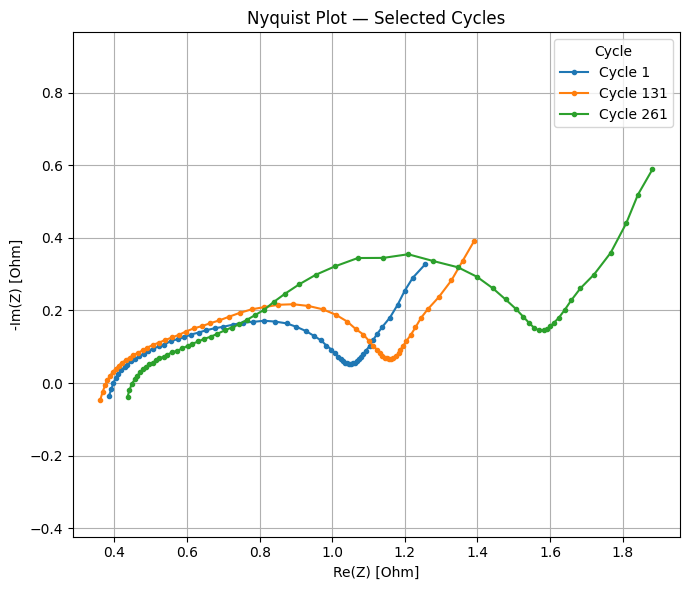

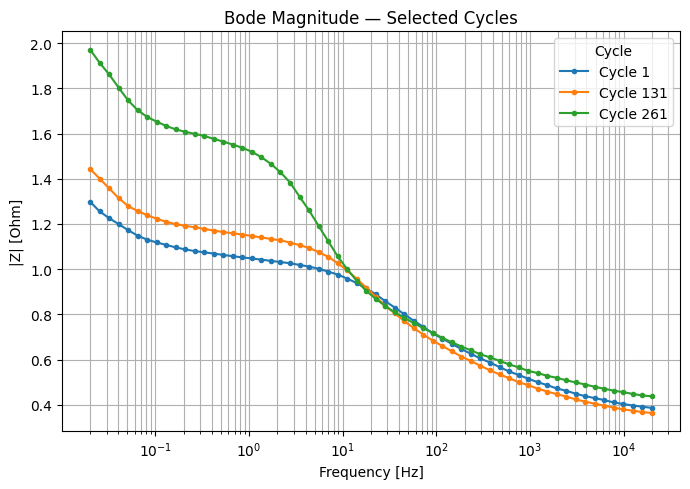

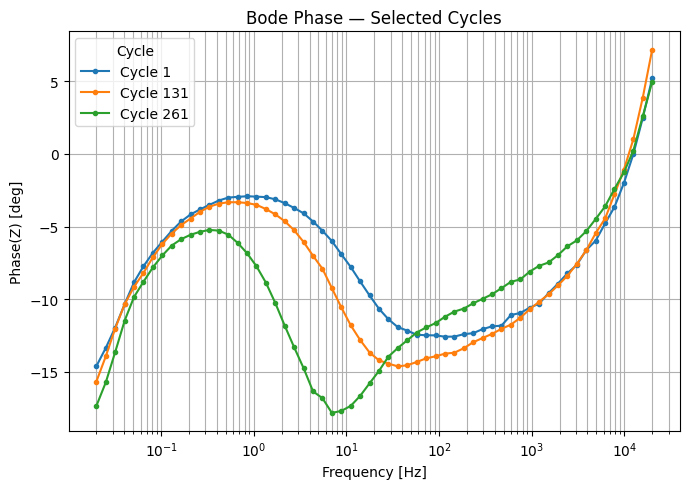

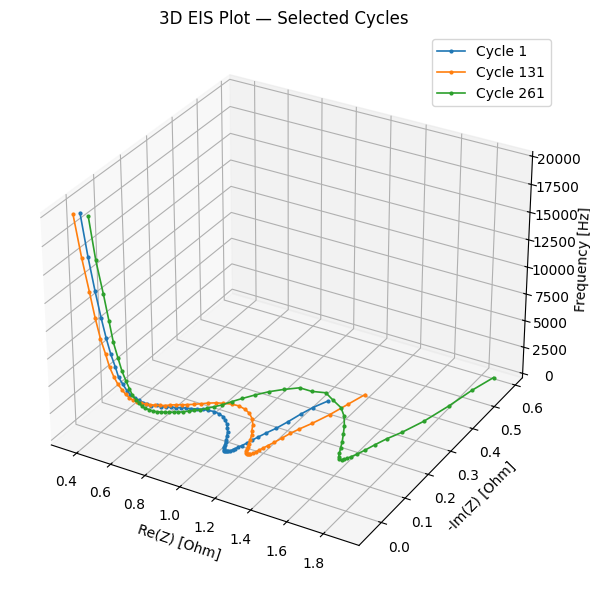

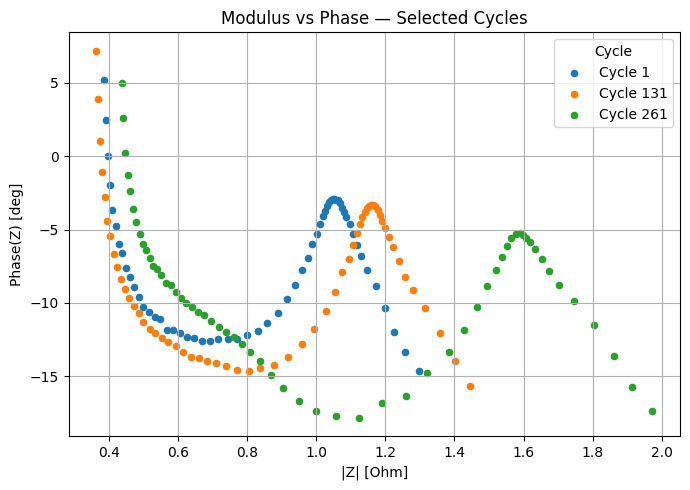

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

# Step 1: Find EIS-related .txt files
candidates = [str(p) for p in Path("//Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/data/EIS_state_V").rglob("*.txt") if "EIS" in str(p)]
print("Candidates with 'EIS' in the path:", len(candidates))
print("Example file:", candidates[0])  # First EIS file found

# Step 2: Load the first file
df = pd.read_csv(candidates[0], sep='\t', engine='python')

# Clean up column names by removing leading/trailing spaces
df.columns = [col.strip() for col in df.columns]

# Ensure selected columns are numeric (convert strings or missing values to NaN)
numeric_cols = ['time/s', 'cycle number', 'freq/Hz', 'Re(Z)/Ohm', '-Im(Z)/Ohm', '|Z|/Ohm', 'Phase(Z)/deg']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Identify unique cycles in the data
cycles = df['cycle number'].dropna().unique()

# Sort cycles
cycles = np.sort(cycles)

# Pick 3 cycles: first, middle, last
if len(cycles) > 2:
    selected_cycles = [cycles[0], cycles[len(cycles)//2], cycles[-1]]
else:
    selected_cycles = cycles  # if less than 3 available

print("Selected cycles:", selected_cycles)

        

plt.figure(figsize=(7, 6))

colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, cycle in enumerate(selected_cycles):
    df_cycle = df[df['cycle number'] == cycle].sort_values('freq/Hz', ascending=False)

    plt.plot(
        df_cycle['Re(Z)/Ohm'],
        df_cycle['-Im(Z)/Ohm'],
        marker='o',
        markersize=3,
        linewidth=1.5,
        color=colors[i % len(colors)],
        label=f'Cycle {int(cycle)}'
    )

plt.xlabel('Re(Z) [Ohm]')
plt.ylabel('-Im(Z) [Ohm]')
plt.title('Nyquist Plot — Selected Cycles')
plt.grid(True)
plt.axis('equal')
plt.legend(title="Cycle")
plt.tight_layout()
plt.show()

# Bode Magnitude Plot: Frequency vs |Z|
plt.figure(figsize=(7, 5))

colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, cycle in enumerate(selected_cycles):
    df_cycle = df[df['cycle number'] == cycle].sort_values('freq/Hz', ascending=False)

    plt.semilogx(
        df_cycle['freq/Hz'],
        df_cycle['|Z|/Ohm'],
        marker='o',
        markersize=3,
        linewidth=1.5,
        color=colors[i % len(colors)],
        label=f'Cycle {int(cycle)}'
    )

plt.xlabel('Frequency [Hz]')
plt.ylabel('|Z| [Ohm]')
plt.title('Bode Magnitude — Selected Cycles')
plt.grid(True, which='both')
plt.legend(title="Cycle")
plt.tight_layout()
plt.show()

# Bode Phase Plot: Frequency vs Phase
plt.figure(figsize=(7, 5))

for i, cycle in enumerate(selected_cycles):
    df_cycle = df[df['cycle number'] == cycle].sort_values('freq/Hz', ascending=False)

    plt.semilogx(
        df_cycle['freq/Hz'],
        df_cycle['Phase(Z)/deg'],
        marker='o',
        markersize=3,
        linewidth=1.5,
        color=colors[i % len(colors)],
        label=f'Cycle {int(cycle)}'
    )

plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase(Z) [deg]')
plt.title('Bode Phase — Selected Cycles')
plt.grid(True, which='both')
plt.legend(title="Cycle")
plt.tight_layout()
plt.show()

# 3D Plot: Re(Z), -Im(Z), Frequency
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for i, cycle in enumerate(selected_cycles):
    df_cycle = df[df['cycle number'] == cycle].sort_values('freq/Hz', ascending=False)

    ax.plot(
        df_cycle['Re(Z)/Ohm'],
        df_cycle['-Im(Z)/Ohm'],
        df_cycle['freq/Hz'],
        marker='o',
        markersize=2,
        linewidth=1.2,
        color=colors[i % len(colors)],
        label=f'Cycle {int(cycle)}'
    )

ax.set_xlabel('Re(Z) [Ohm]')
ax.set_ylabel('-Im(Z) [Ohm]')
ax.set_zlabel('Frequency [Hz]')
ax.set_title('3D EIS Plot — Selected Cycles')
ax.legend()
plt.tight_layout()
plt.show()

# Modulus vs Phase Plot: Color-coded by Frequency
plt.figure(figsize=(7, 5))

for i, cycle in enumerate(selected_cycles):
    df_cycle = df[df['cycle number'] == cycle]

    plt.scatter(
        df_cycle['|Z|/Ohm'],
        df_cycle['Phase(Z)/deg'],
        s=20,
        color=colors[i % len(colors)],
        label=f'Cycle {int(cycle)}'
    )

plt.xlabel('|Z| [Ohm]')
plt.ylabel('Phase(Z) [deg]')
plt.title('Modulus vs Phase — Selected Cycles')
plt.grid(True)
plt.legend(title="Cycle")
plt.tight_layout()
plt.show()


   


Temperature 25°C
Files found: 8
Selected cycles for 25°C: [np.float64(1.0), np.float64(138.0), np.float64(275.0)]


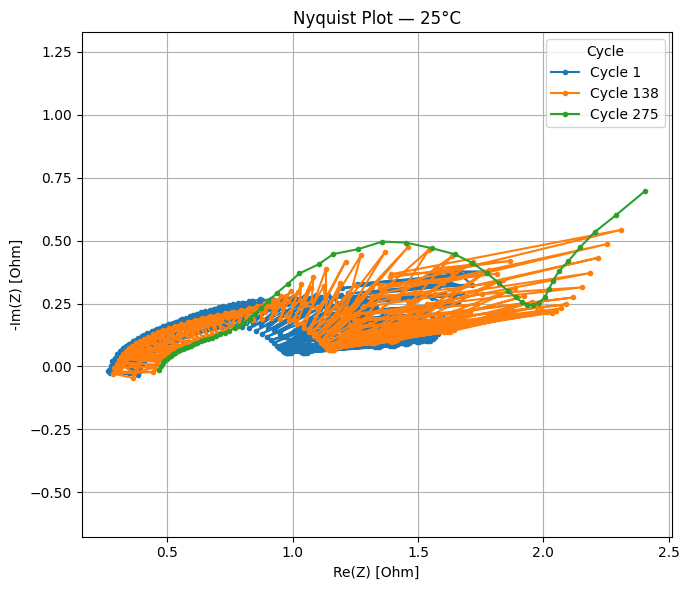

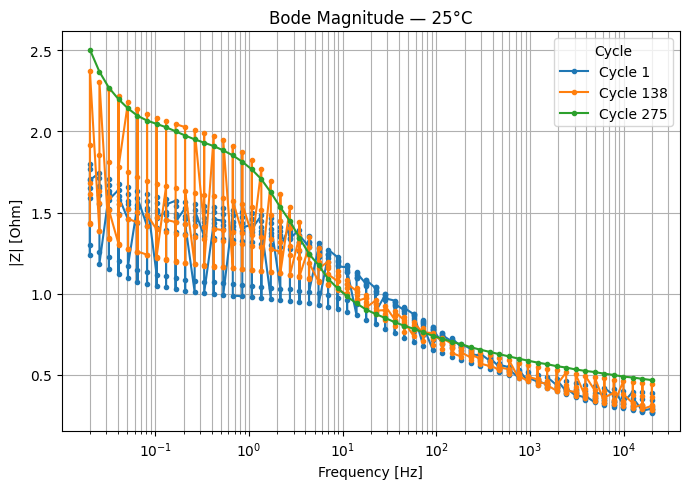

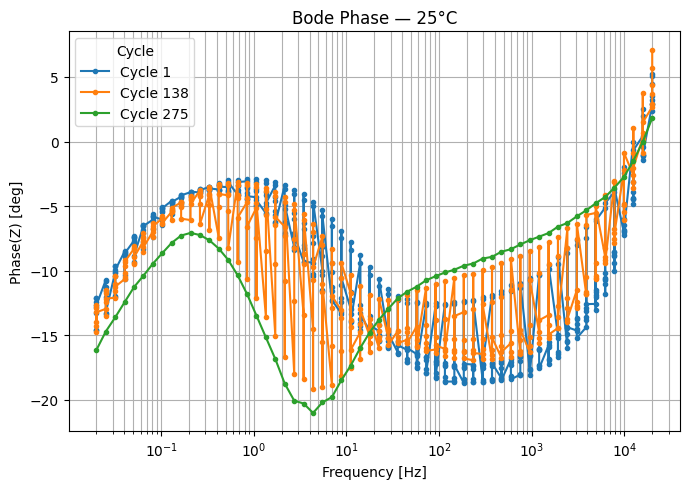

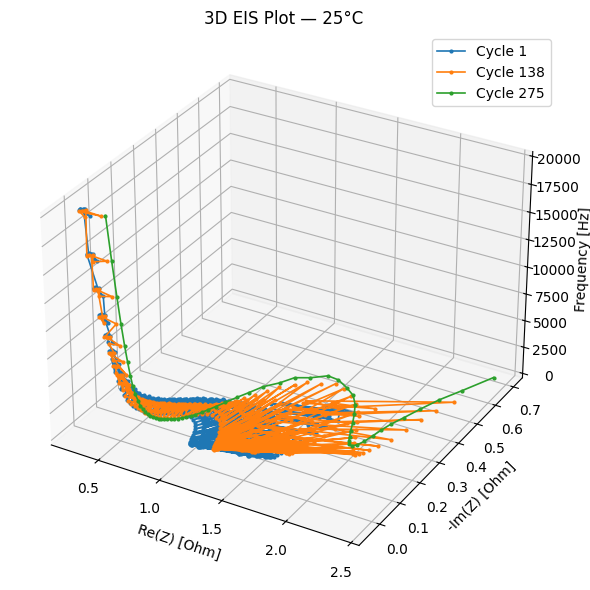

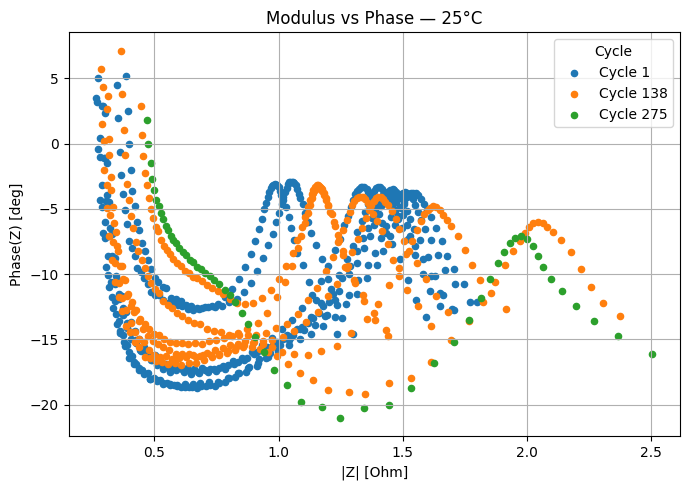


Temperature 35°C
Files found: 2
Selected cycles for 35°C: [np.float64(1.0), np.float64(164.0), np.float64(327.0)]


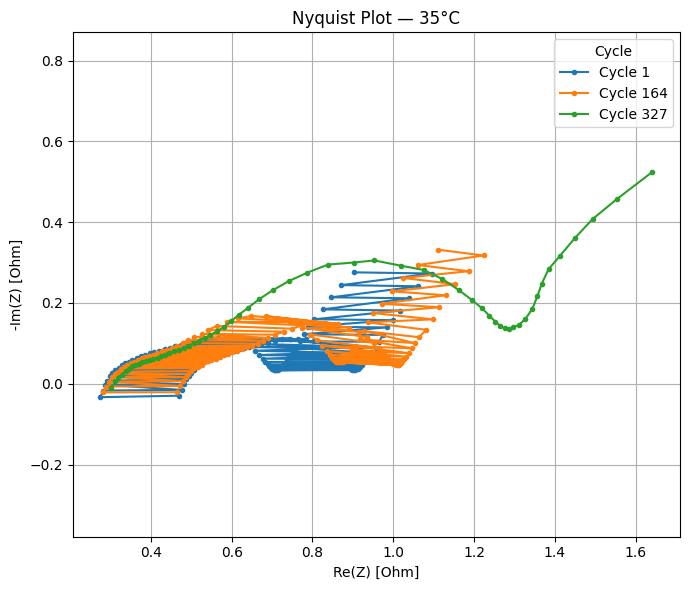

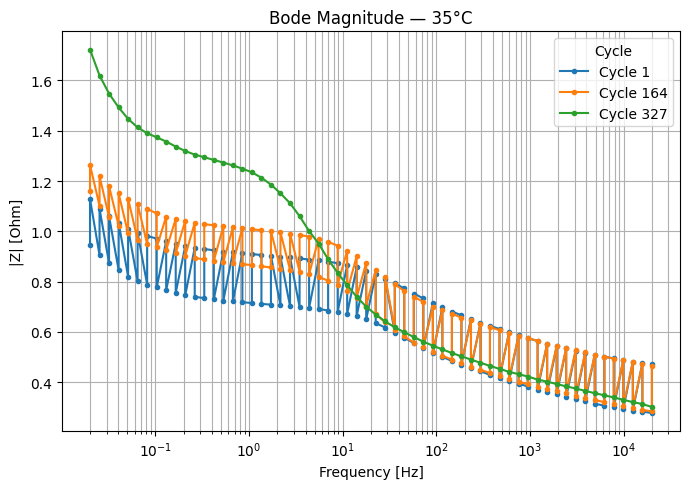

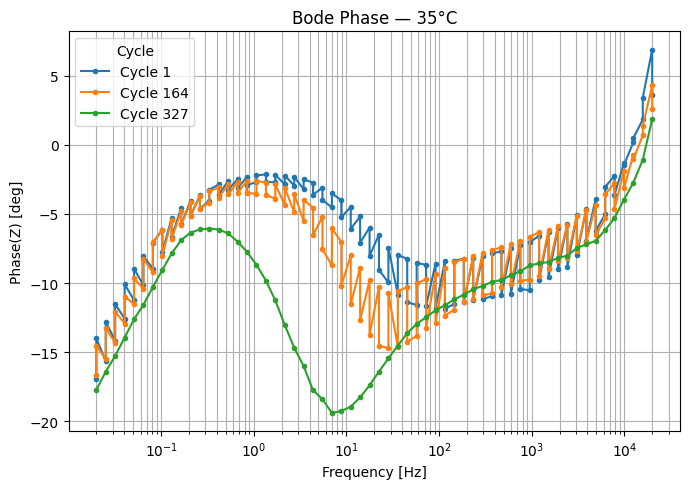

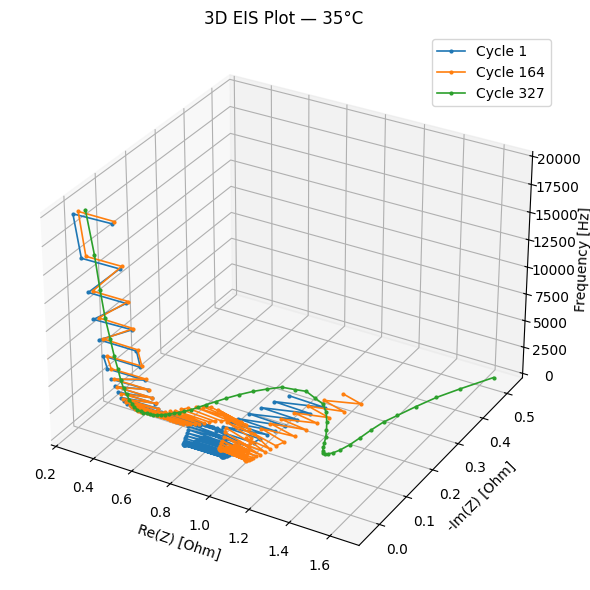

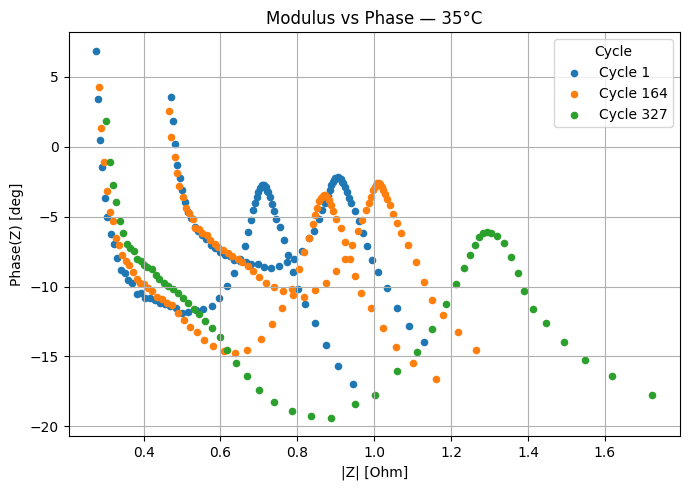


Temperature 45°C
Files found: 2
Selected cycles for 45°C: [np.float64(1.0), np.float64(156.0), np.float64(310.0)]


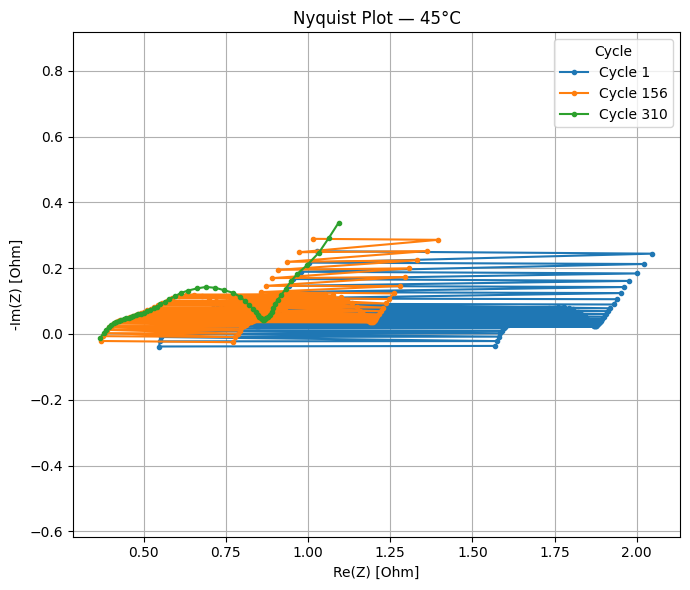

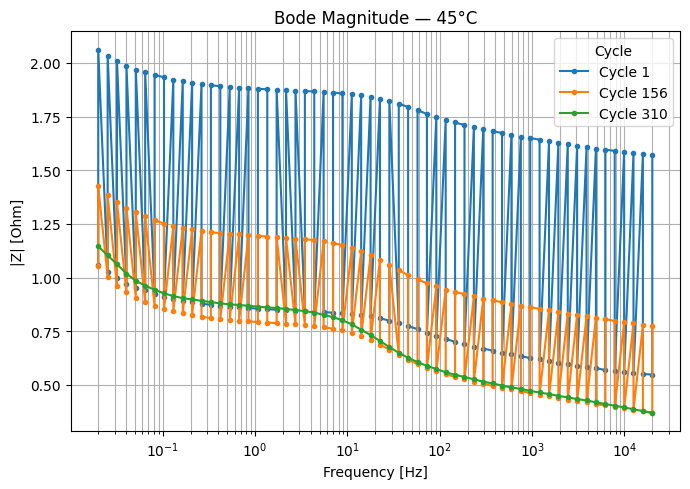

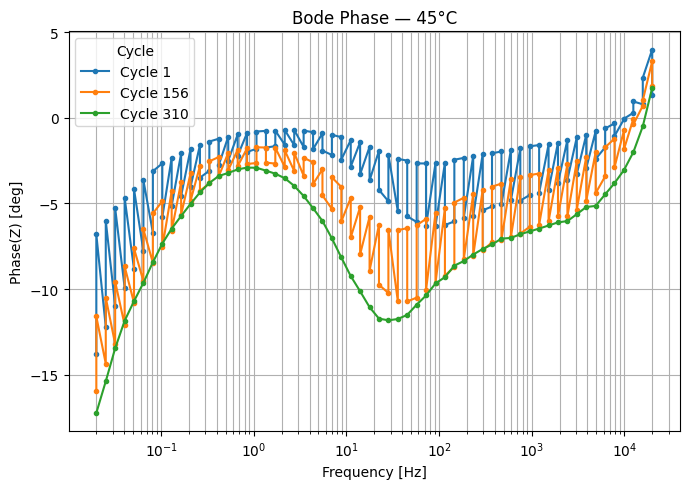

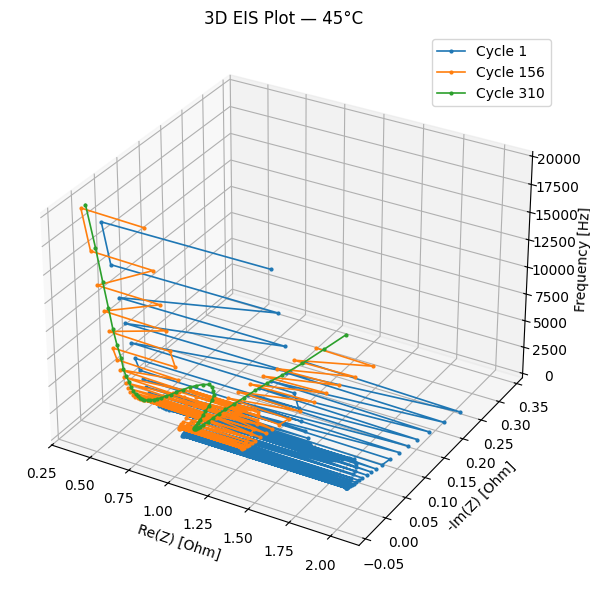

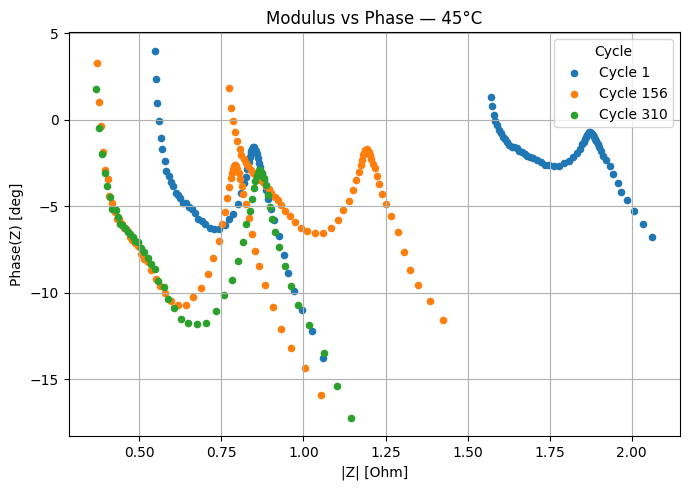

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D

# =========================
# SETTINGS
# =========================
base_folder = Path("/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/data/EIS_state_V")

temperatures = [25, 35, 45]   # change if needed
colors = ['tab:blue', 'tab:orange', 'tab:green']

numeric_cols = [
    'time/s', 'cycle number', 'freq/Hz',
    'Re(Z)/Ohm', '-Im(Z)/Ohm',
    '|Z|/Ohm', 'Phase(Z)/deg'
]

# =========================
# FUNCTION TO LOAD FILES
# =========================
def load_temperature_data(temp):
    """
    Finds and loads all EIS txt files for a given temperature.
    Assumes temperature is present in filename/path like 25C, 35C, 45C.
    """
    files = [
        p for p in base_folder.rglob("*.txt")
        if "EIS" in str(p) and f"{temp}C" in str(p)
    ]

    print(f"\nTemperature {temp}°C")
    print("Files found:", len(files))

    if len(files) == 0:
        return None

    dfs = []

    for file in files:
        df = pd.read_csv(file, sep="\t", engine="python")
        df.columns = [col.strip() for col in df.columns]

        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        df["source_file"] = file.name
        df["temperature"] = temp
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


# =========================
# FUNCTION TO SELECT CYCLES
# =========================
def get_selected_cycles(df):
    cycles = df["cycle number"].dropna().unique()
    cycles = np.sort(cycles)

    if len(cycles) > 2:
        selected_cycles = [cycles[0], cycles[len(cycles)//2], cycles[-1]]
    else:
        selected_cycles = cycles

    return selected_cycles


# =========================
# FUNCTION TO MAKE PLOTS
# =========================
def plot_eis_for_temperature(df, temp, selected_cycles):

    # 1. Nyquist Plot
    plt.figure(figsize=(7, 6))

    for i, cycle in enumerate(selected_cycles):
        df_cycle = df[df["cycle number"] == cycle].sort_values("freq/Hz", ascending=False)

        plt.plot(
            df_cycle["Re(Z)/Ohm"],
            df_cycle["-Im(Z)/Ohm"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=colors[i % len(colors)],
            label=f"Cycle {int(cycle)}"
        )

    plt.xlabel("Re(Z) [Ohm]")
    plt.ylabel("-Im(Z) [Ohm]")
    plt.title(f"Nyquist Plot — {temp}°C")
    plt.grid(True)
    plt.axis("equal")
    plt.legend(title="Cycle")
    plt.tight_layout()
    plt.show()

    # 2. Bode Magnitude Plot
    plt.figure(figsize=(7, 5))

    for i, cycle in enumerate(selected_cycles):
        df_cycle = df[df["cycle number"] == cycle].sort_values("freq/Hz", ascending=False)

        plt.semilogx(
            df_cycle["freq/Hz"],
            df_cycle["|Z|/Ohm"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=colors[i % len(colors)],
            label=f"Cycle {int(cycle)}"
        )

    plt.xlabel("Frequency [Hz]")
    plt.ylabel("|Z| [Ohm]")
    plt.title(f"Bode Magnitude — {temp}°C")
    plt.grid(True, which="both")
    plt.legend(title="Cycle")
    plt.tight_layout()
    plt.show()

    # 3. Bode Phase Plot
    plt.figure(figsize=(7, 5))

    for i, cycle in enumerate(selected_cycles):
        df_cycle = df[df["cycle number"] == cycle].sort_values("freq/Hz", ascending=False)

        plt.semilogx(
            df_cycle["freq/Hz"],
            df_cycle["Phase(Z)/deg"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=colors[i % len(colors)],
            label=f"Cycle {int(cycle)}"
        )

    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Phase(Z) [deg]")
    plt.title(f"Bode Phase — {temp}°C")
    plt.grid(True, which="both")
    plt.legend(title="Cycle")
    plt.tight_layout()
    plt.show()

    # 4. 3D Plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    for i, cycle in enumerate(selected_cycles):
        df_cycle = df[df["cycle number"] == cycle].sort_values("freq/Hz", ascending=False)

        ax.plot(
            df_cycle["Re(Z)/Ohm"],
            df_cycle["-Im(Z)/Ohm"],
            df_cycle["freq/Hz"],
            marker="o",
            markersize=2,
            linewidth=1.2,
            color=colors[i % len(colors)],
            label=f"Cycle {int(cycle)}"
        )

    ax.set_xlabel("Re(Z) [Ohm]")
    ax.set_ylabel("-Im(Z) [Ohm]")
    ax.set_zlabel("Frequency [Hz]")
    ax.set_title(f"3D EIS Plot — {temp}°C")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # 5. Modulus vs Phase Plot
    plt.figure(figsize=(7, 5))

    for i, cycle in enumerate(selected_cycles):
        df_cycle = df[df["cycle number"] == cycle]

        plt.scatter(
            df_cycle["|Z|/Ohm"],
            df_cycle["Phase(Z)/deg"],
            s=20,
            color=colors[i % len(colors)],
            label=f"Cycle {int(cycle)}"
        )

    plt.xlabel("|Z| [Ohm]")
    plt.ylabel("Phase(Z) [deg]")
    plt.title(f"Modulus vs Phase — {temp}°C")
    plt.grid(True)
    plt.legend(title="Cycle")
    plt.tight_layout()
    plt.show()


# =========================
# MAIN LOOP
# =========================
for temp in temperatures:
    df_temp = load_temperature_data(temp)

    if df_temp is None:
        print(f"No data found for {temp}°C")
        continue

    selected_cycles = get_selected_cycles(df_temp)
    print(f"Selected cycles for {temp}°C:", selected_cycles)

    plot_eis_for_temperature(df_temp, temp, selected_cycles)

In [ ]:
plots for all cycles

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Find EIS-related .txt files
candidates = [str(p) for p in Path("//Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/data/EIS_state_IX").rglob("*.txt") if "EIS" in str(p)]
print("Candidates with 'EIS' in the path:", len(candidates))
print("Example file:", candidates[0])  # First EIS file found

# Step 2: Load the first file
df = pd.read_csv(candidates[0], sep='\t', engine='python')

# Clean up column names by removing leading/trailing spaces
df.columns = [col.strip() for col in df.columns]

# Ensure selected columns are numeric (convert strings or missing values to NaN)
numeric_cols = ['time/s', 'cycle number', 'freq/Hz', 'Re(Z)/Ohm', '-Im(Z)/Ohm', '|Z|/Ohm', 'Phase(Z)/deg']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Identify unique cycles in the data
cycles = df['cycle number'].dropna().unique()
        

# Generate plots for each individual cycle
for cycle in cycles:
    # Filter and sort data for the current cycle by descending frequency
    df_cycle = df[df['cycle number'] == cycle].sort_values('freq/Hz', ascending=False)

    # Nyquist Plot: Re(Z) vs -Im(Z)
    plt.figure(figsize=(6, 5))
    plt.plot(df_cycle['Re(Z)/Ohm'], df_cycle['-Im(Z)/Ohm'], marker='o')
    plt.xlabel('Re(Z) [Ohm]')
    plt.ylabel('-Im(Z) [Ohm]')
    plt.title(f'Nyquist Plot - Cycle {int(cycle)}')
    plt.grid(True)
    plt.axis('equal')
    plt.show()

    '''# Bode Magnitude Plot: Frequency vs |Z|
    plt.figure(figsize=(6, 5))
    plt.semilogx(df_cycle['freq/Hz'], df_cycle['|Z|/Ohm'], marker='o')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('|Z| [Ohm]')
    plt.title(f'Bode Magnitude Plot - Cycle {int(cycle)}')
    plt.grid(True)
    plt.show()

    # Bode Phase Plot: Frequency vs Phase
    plt.figure(figsize=(6, 5))
    plt.semilogx(df_cycle['freq/Hz'], df_cycle['Phase(Z)/deg'], marker='o', color='r')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Phase(Z) [deg]')
    plt.title(f'Bode Phase Plot - Cycle {int(cycle)}')
    plt.grid(True)
    plt.show()

    # 3D Plot: Re(Z), -Im(Z), Frequency
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(df_cycle['Re(Z)/Ohm'], df_cycle['-Im(Z)/Ohm'], df_cycle['freq/Hz'], marker='o')
    ax.set_xlabel('Re(Z) [Ohm]')
    ax.set_ylabel('-Im(Z) [Ohm]')
    ax.set_zlabel('Frequency [Hz]')
    ax.set_title(f'3D EIS Plot - Cycle {int(cycle)}')
    plt.show()

    # Modulus vs Phase Plot: Color-coded by Frequency
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(df_cycle['|Z|/Ohm'], df_cycle['Phase(Z)/deg'], c=df_cycle['freq/Hz'], cmap='viridis')
    plt.colorbar(scatter, label='Frequency [Hz]')
    plt.xlabel('|Z| [Ohm]')
    plt.ylabel('Phase(Z) [deg]')
    plt.title(f'Modulus vs Phase - Cycle {int(cycle)}')
    plt.grid(True)
    plt.show()'''


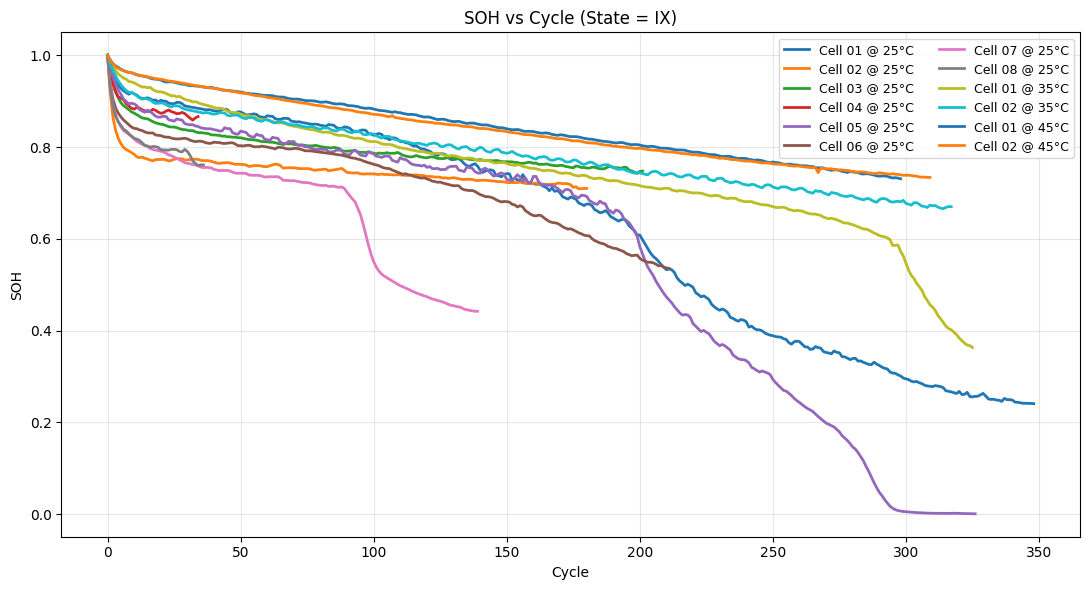

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- load ----
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_state_IX_norm.csv')  # <- change path if needed

# ---- select state (use "IX" because your file shows state as roman numeral) ----
STATE = "IX"   # if you want state 9 but stored as IX in data
d = df[df["state"] == STATE].copy()

# ---- plot ----
plt.figure(figsize=(11, 6))

# one color per temperature (matplotlib will pick default distinct colors)
temps = sorted(d["T_C"].unique())

for T in temps:
    dT = d[d["T_C"] == T]
    for cell_id, g in dT.groupby("cell"):
        g = g.sort_values("cycle")
        plt.plot(g["cycle"], g["SOH"], linewidth=2, label=f"Cell {int(cell_id):02d} @ {int(T)}°C")

plt.title(f"SOH vs Cycle (State = {STATE})")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.grid(True, alpha=0.3)

# Legend can get big; this keeps it readable
plt.legend(ncol=2, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()


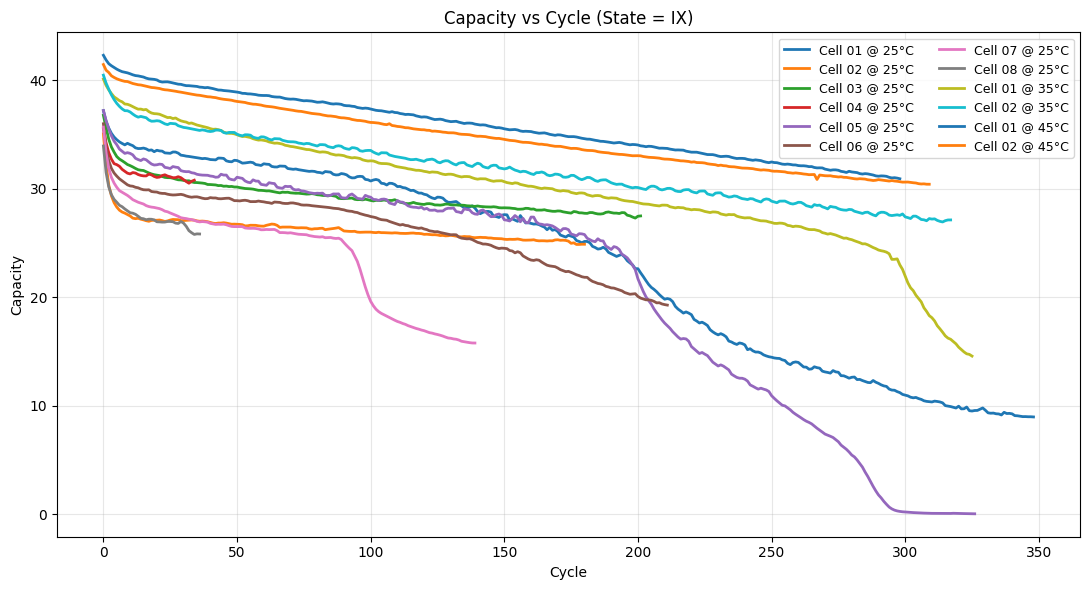

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- load ----
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_state_IX_norm.csv')  # <- change path if needed

# ---- select state (use "IX" because your file shows state as roman numeral) ----
STATE = "IX"   # if you want state 9 but stored as IX in data
d = df[df["state"] == STATE].copy()

# ---- plot ----
plt.figure(figsize=(11, 6))

# one color per temperature (matplotlib will pick default distinct colors)
temps = sorted(d["T_C"].unique())

for T in temps:
    dT = d[d["T_C"] == T]
    for cell_id, g in dT.groupby("cell"):
        g = g.sort_values("cycle")
        plt.plot(g["cycle"], g["capacity"], linewidth=2, label=f"Cell {int(cell_id):02d} @ {int(T)}°C")

plt.title(f"Capacity vs Cycle (State = {STATE})")
plt.xlabel("Cycle")
plt.ylabel("Capacity")
plt.grid(True, alpha=0.3)

# Legend can get big; this keeps it readable
plt.legend(ncol=2, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()


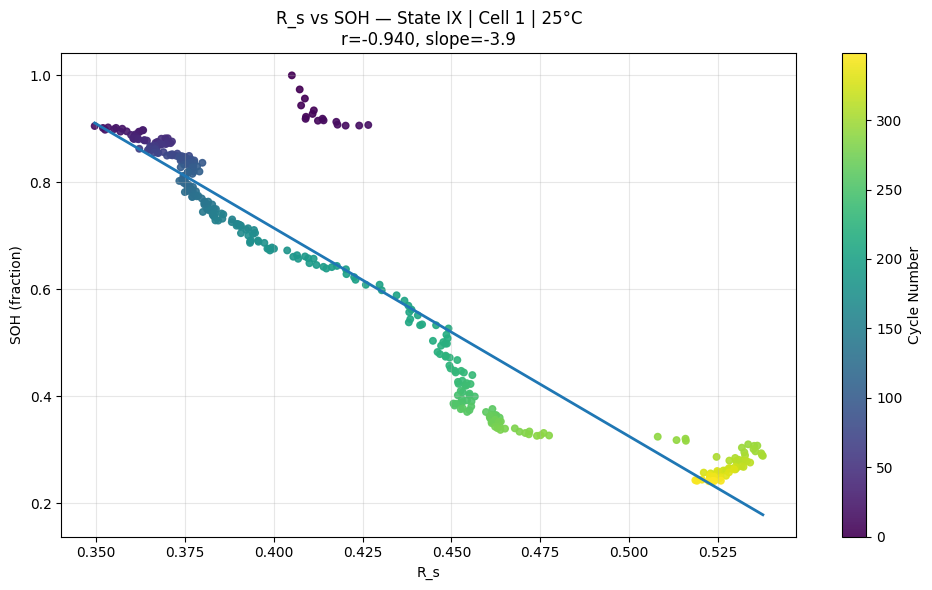

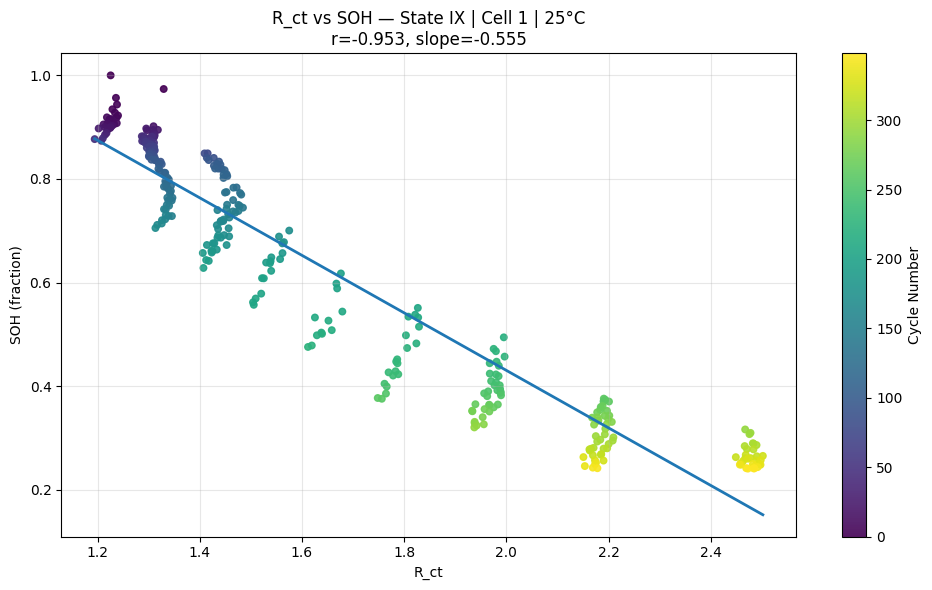

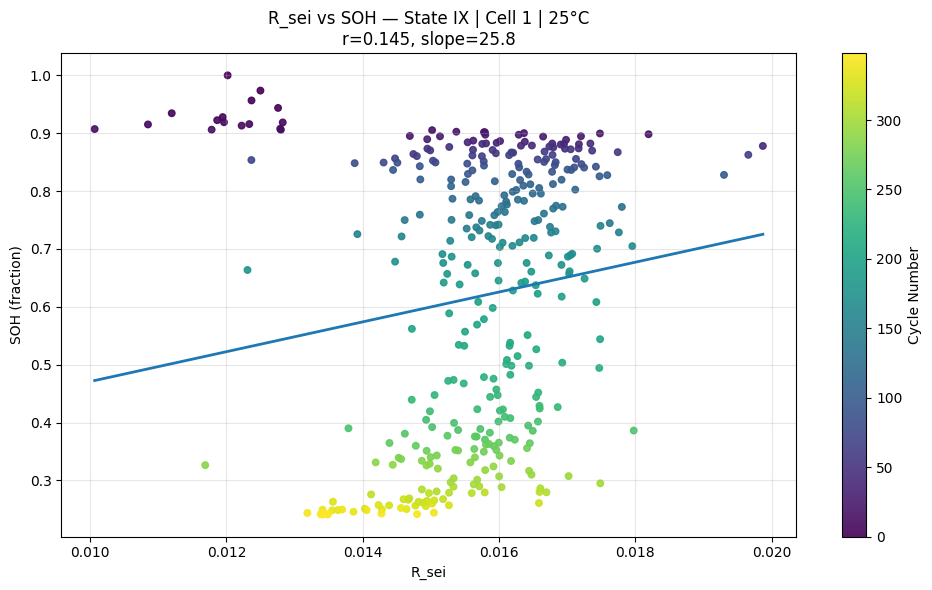

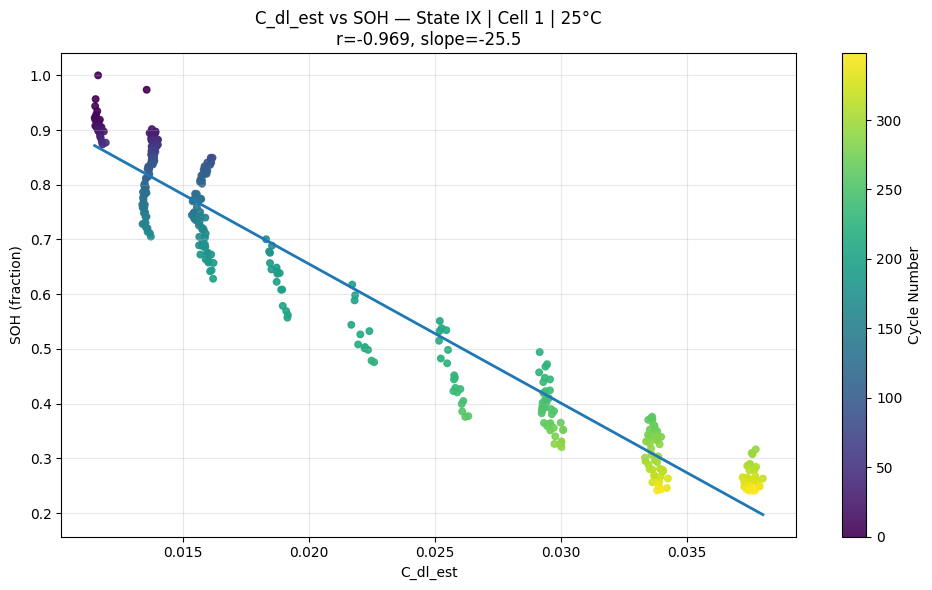

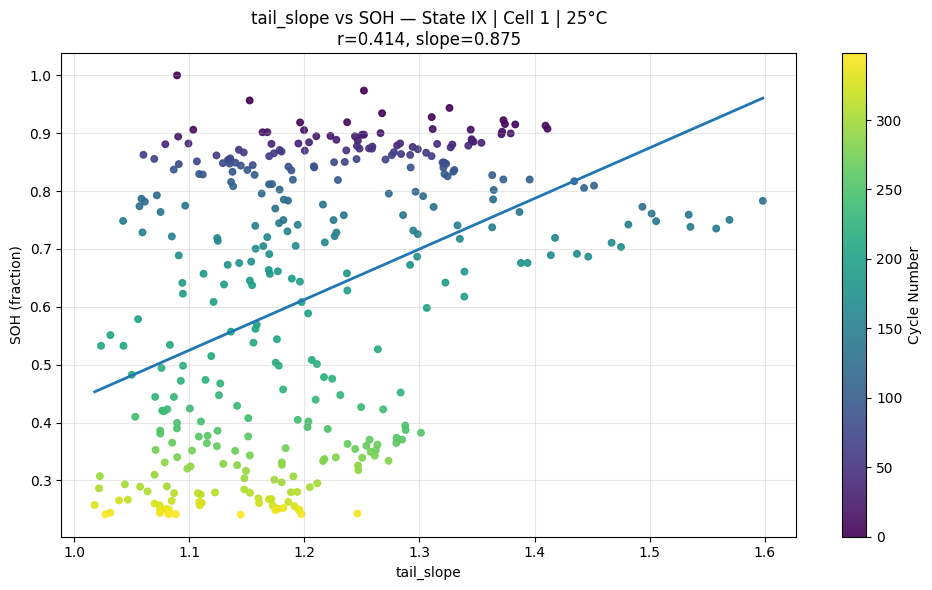

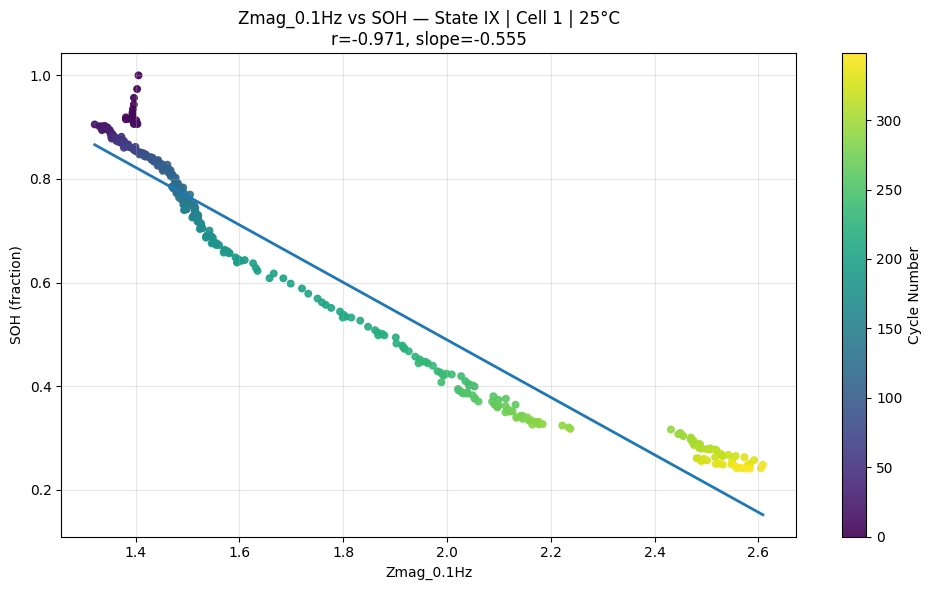

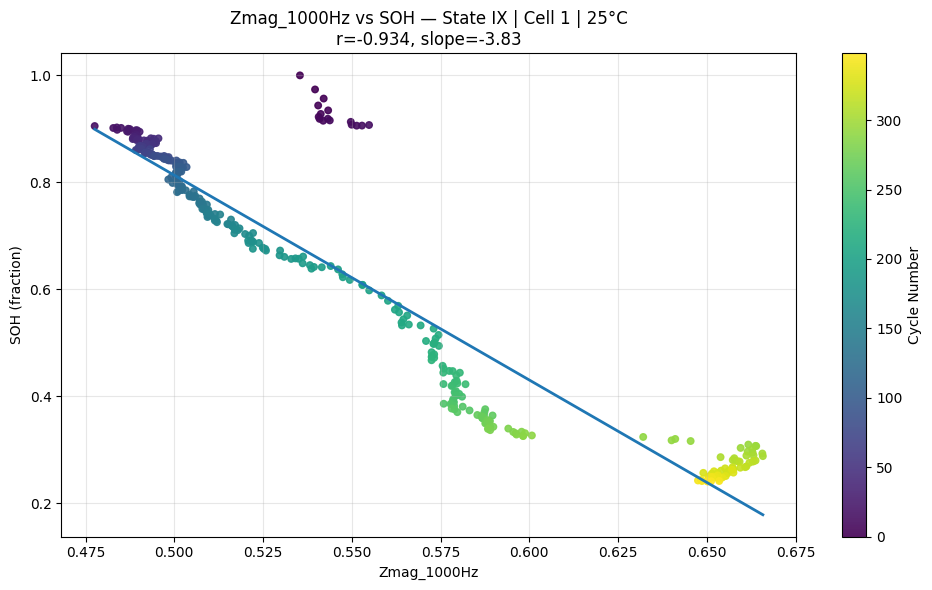

/var/folders/2t/k392bwxd4tb6pyly82dg4pqw0000gn/T/ipykernel_8389/762899199.py:38: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(x, y, 1)
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


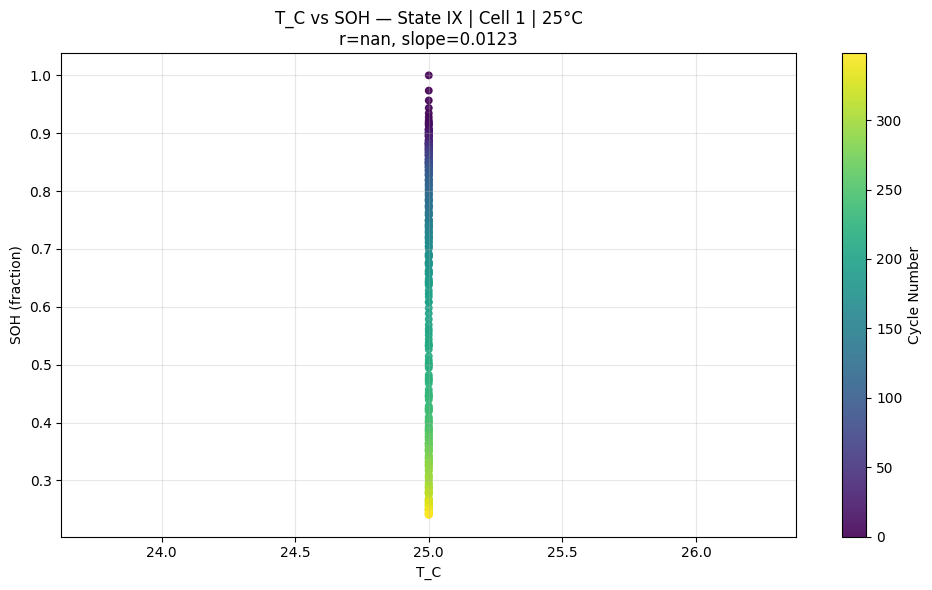

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#df = pd.read_csv("final_7features_state_IX.csv")

STATE = "IX"
CELL_ID = 1
TEMP_C = 25 # set None to ignore

features = [
    "R_s","R_ct","R_sei","C_dl_est","tail_slope","Zmag_0.1Hz","Zmag_1000Hz","T_C"
]

d = df[df["state"].astype(str) == str(STATE)].copy()
d = d[d["cell"] == CELL_ID].copy()
if TEMP_C is not None:
    d = d[d["T_C"] == TEMP_C].copy()

d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=["cycle","SOH"] + features).sort_values("cycle")

cycles = d["cycle"].to_numpy()
norm = plt.Normalize(vmin=np.nanmin(cycles), vmax=np.nanmax(cycles))
cmap = plt.cm.viridis

for feat in features:
    x = pd.to_numeric(d[feat], errors="coerce").to_numpy()
    y = pd.to_numeric(d["SOH"], errors="coerce").to_numpy()
    c = pd.to_numeric(d["cycle"], errors="coerce").to_numpy()

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)
    x, y, c = x[mask], y[mask], c[mask]

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, c=c, cmap=cmap, norm=norm, s=22, alpha=0.9)

    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        r = np.corrcoef(x, y)[0, 1]
        xx = np.linspace(np.min(x), np.max(x), 200)
        plt.plot(xx, slope * xx + intercept, linewidth=2)
        plt.title(f"{feat} vs SOH — State {STATE} | Cell {CELL_ID}" + (f" | {TEMP_C}°C" if TEMP_C is not None else "") + f"\nr={r:.3f}, slope={slope:.3g}")
    else:
        plt.title(f"{feat} vs SOH — State {STATE} | Cell {CELL_ID}")

    plt.xlabel(feat)
    plt.ylabel("SOH (fraction)")
    plt.grid(True, alpha=0.3)
    cbar = plt.colorbar()
    cbar.set_label("Cycle Number")
    plt.tight_layout()
    plt.show()


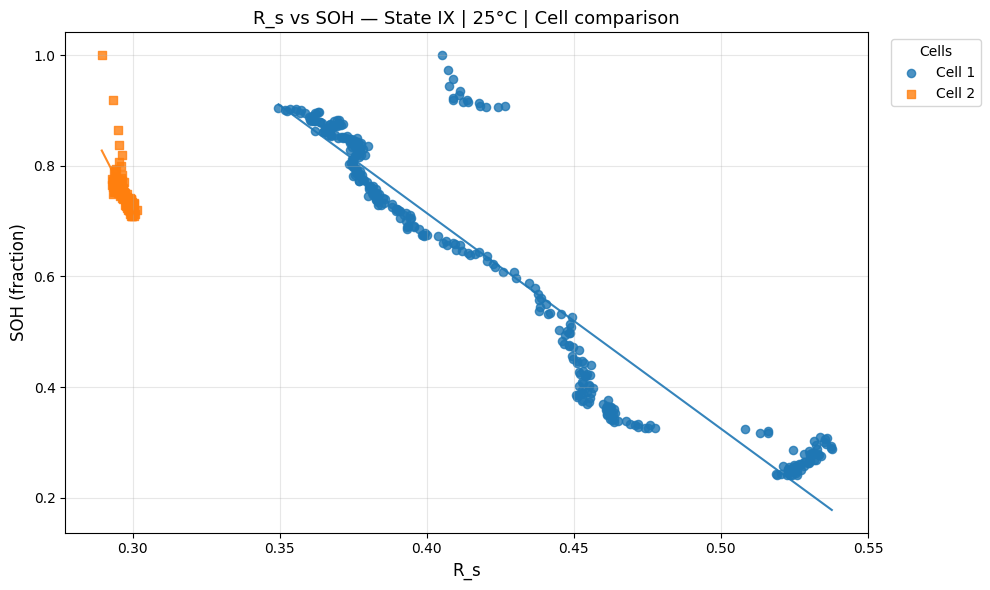

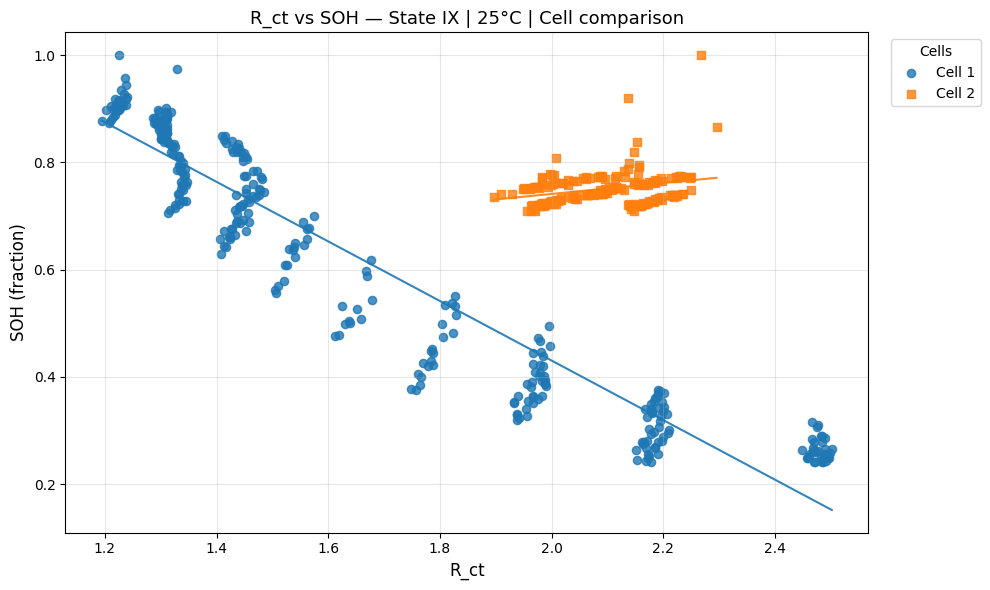

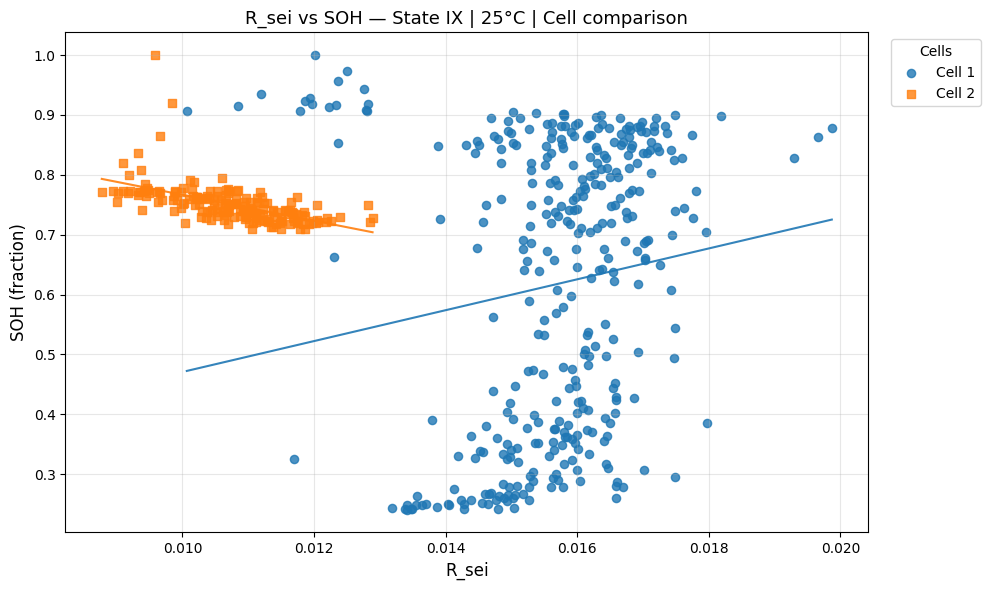

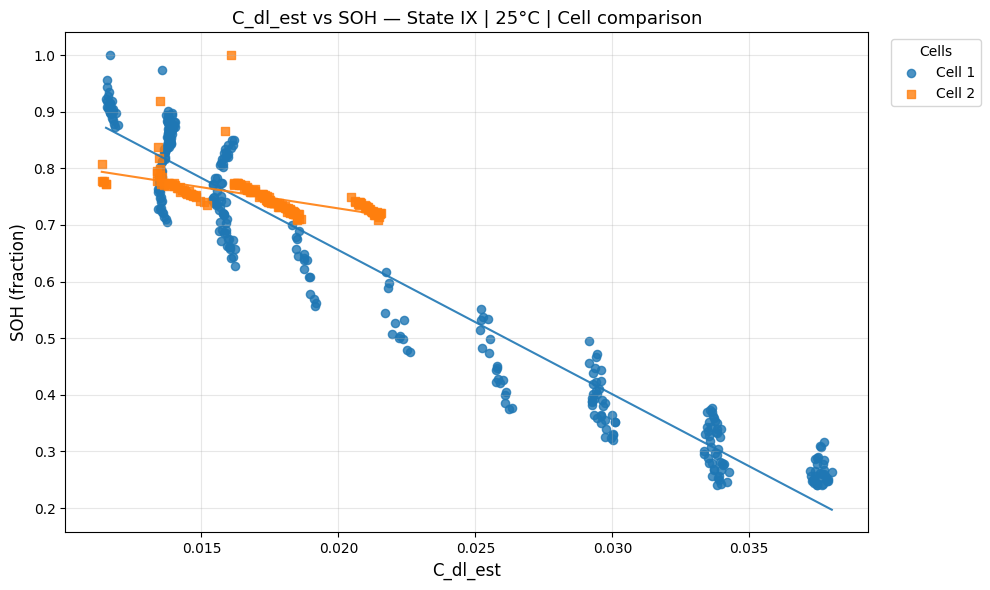

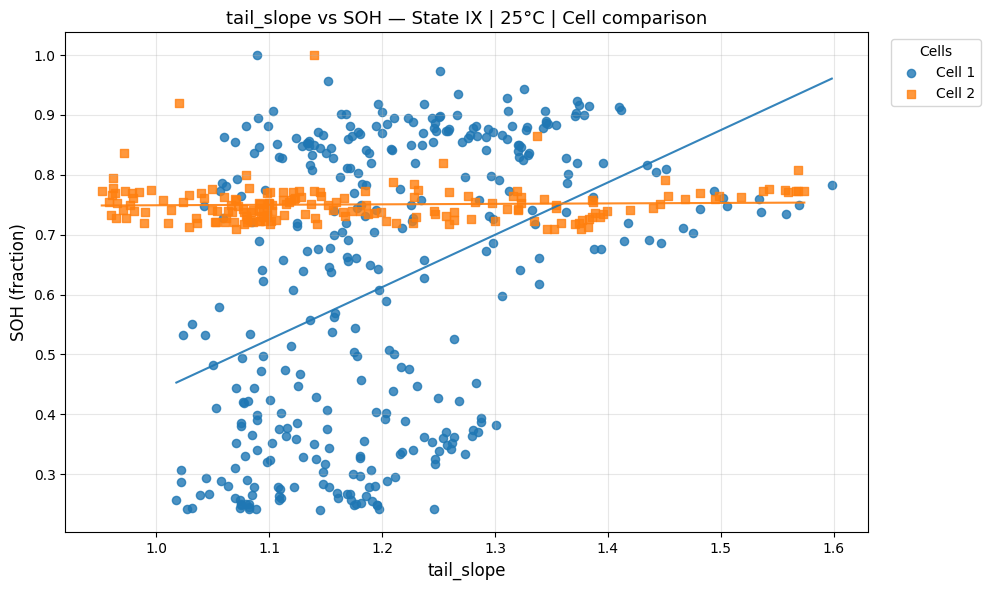

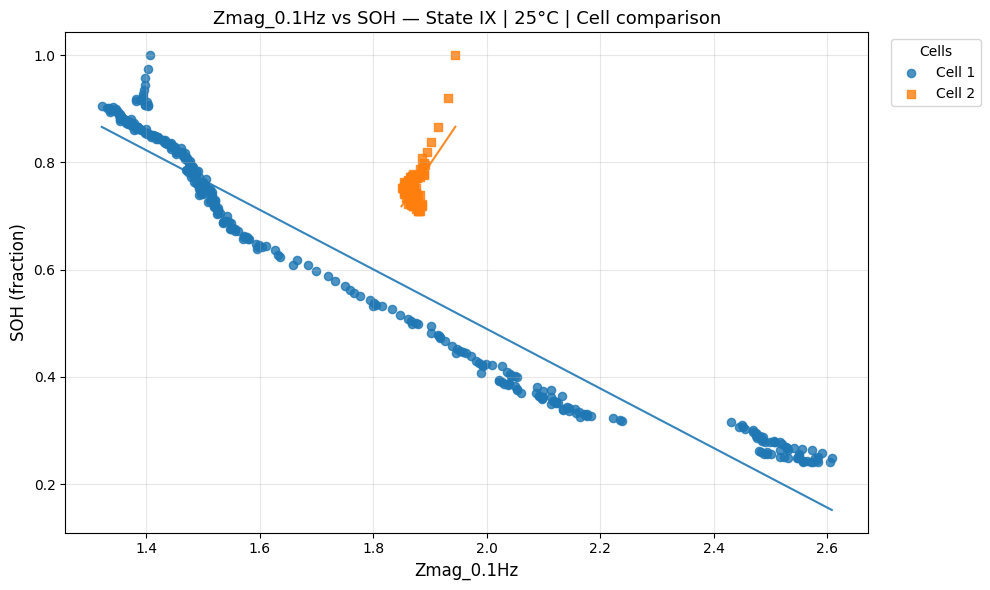

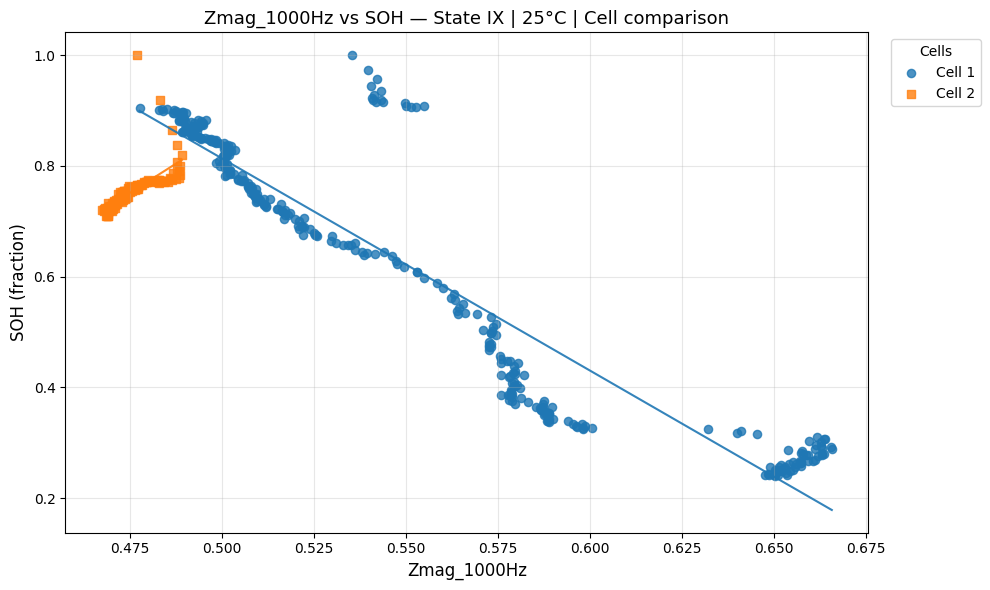

/var/folders/2t/k392bwxd4tb6pyly82dg4pqw0000gn/T/ipykernel_8389/3069299863.py:72: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(x, y, 1)
/var/folders/2t/k392bwxd4tb6pyly82dg4pqw0000gn/T/ipykernel_8389/3069299863.py:72: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(x, y, 1)


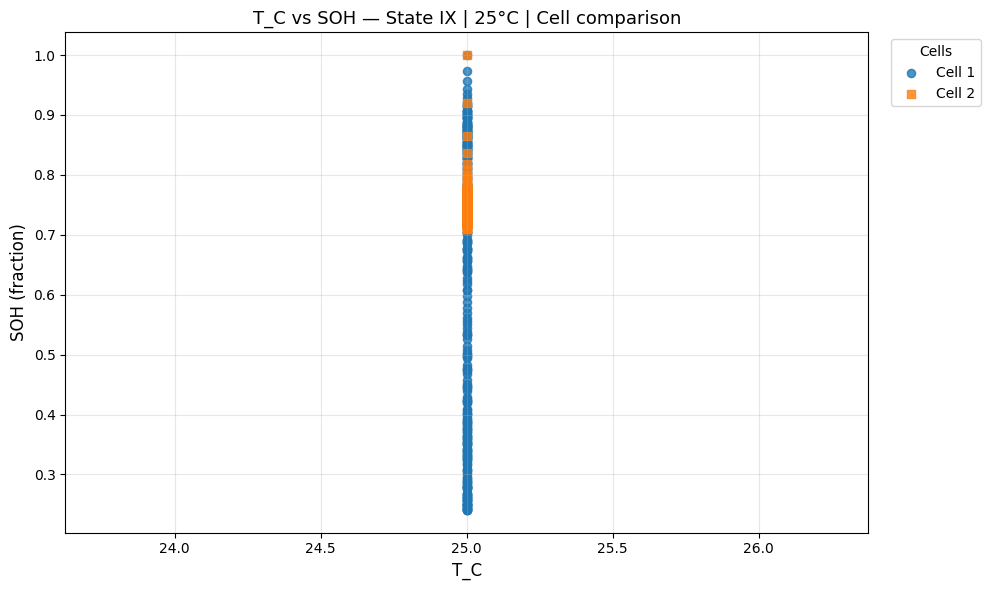

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
STATE = "IX"
TEMP_C = 25          # set None to ignore temperature filter
CELL_IDS = [1, 2]      # None = use all cells available, or set like [1, 2, 3, 4]

features = [
    "R_s", "R_ct", "R_sei", "C_dl_est",
    "tail_slope", "Zmag_0.1Hz", "Zmag_1000Hz", "T_C"
]

# =========================
# FILTER DATA
# =========================
d = df[df["state"].astype(str) == str(STATE)].copy()

if TEMP_C is not None:
    d = d[d["T_C"] == TEMP_C].copy()

if CELL_IDS is not None:
    d = d[d["cell"].isin(CELL_IDS)].copy()

d = d.replace([np.inf, -np.inf], np.nan)
d = d.dropna(subset=["cycle", "SOH", "cell"] + features)
d = d.sort_values(["cell", "cycle"]).copy()

# available cells
cells = sorted(d["cell"].unique())

# markers for different cells
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']
marker_map = {cell: markers[i % len(markers)] for i, cell in enumerate(cells)}

# colors from matplotlib default cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_map = {cell: colors[i % len(colors)] for i, cell in enumerate(cells)}

# =========================
# PLOT EACH FEATURE
# =========================
for feat in features:
    plt.figure(figsize=(10, 6))

    for cell in cells:
        dc = d[d["cell"] == cell].copy()

        x = pd.to_numeric(dc[feat], errors="coerce").to_numpy()
        y = pd.to_numeric(dc["SOH"], errors="coerce").to_numpy()

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        if len(x) == 0:
            continue

        plt.scatter(
            x, y,
            s=35,
            alpha=0.8,
            marker=marker_map[cell],
            color=color_map[cell],
            label=f"Cell {cell}"
        )

        # Optional regression line per cell
        if len(x) >= 2:
            slope, intercept = np.polyfit(x, y, 1)
            xx = np.linspace(np.min(x), np.max(x), 100)
            plt.plot(
                xx,
                slope * xx + intercept,
                color=color_map[cell],
                linewidth=1.5,
                alpha=0.9
            )

    plt.xlabel(feat, fontsize=12)
    plt.ylabel("SOH (fraction)", fontsize=12)
    plt.title(
        f"{feat} vs SOH — State {STATE}" +
        (f" | {TEMP_C}°C" if TEMP_C is not None else "") +
        " | Cell comparison",
        fontsize=13
    )
    plt.grid(True, alpha=0.3)
    plt.legend(title="Cells", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

/var/folders/2t/k392bwxd4tb6pyly82dg4pqw0000gn/T/ipykernel_8389/1106362972.py:60: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(x, y, 1)


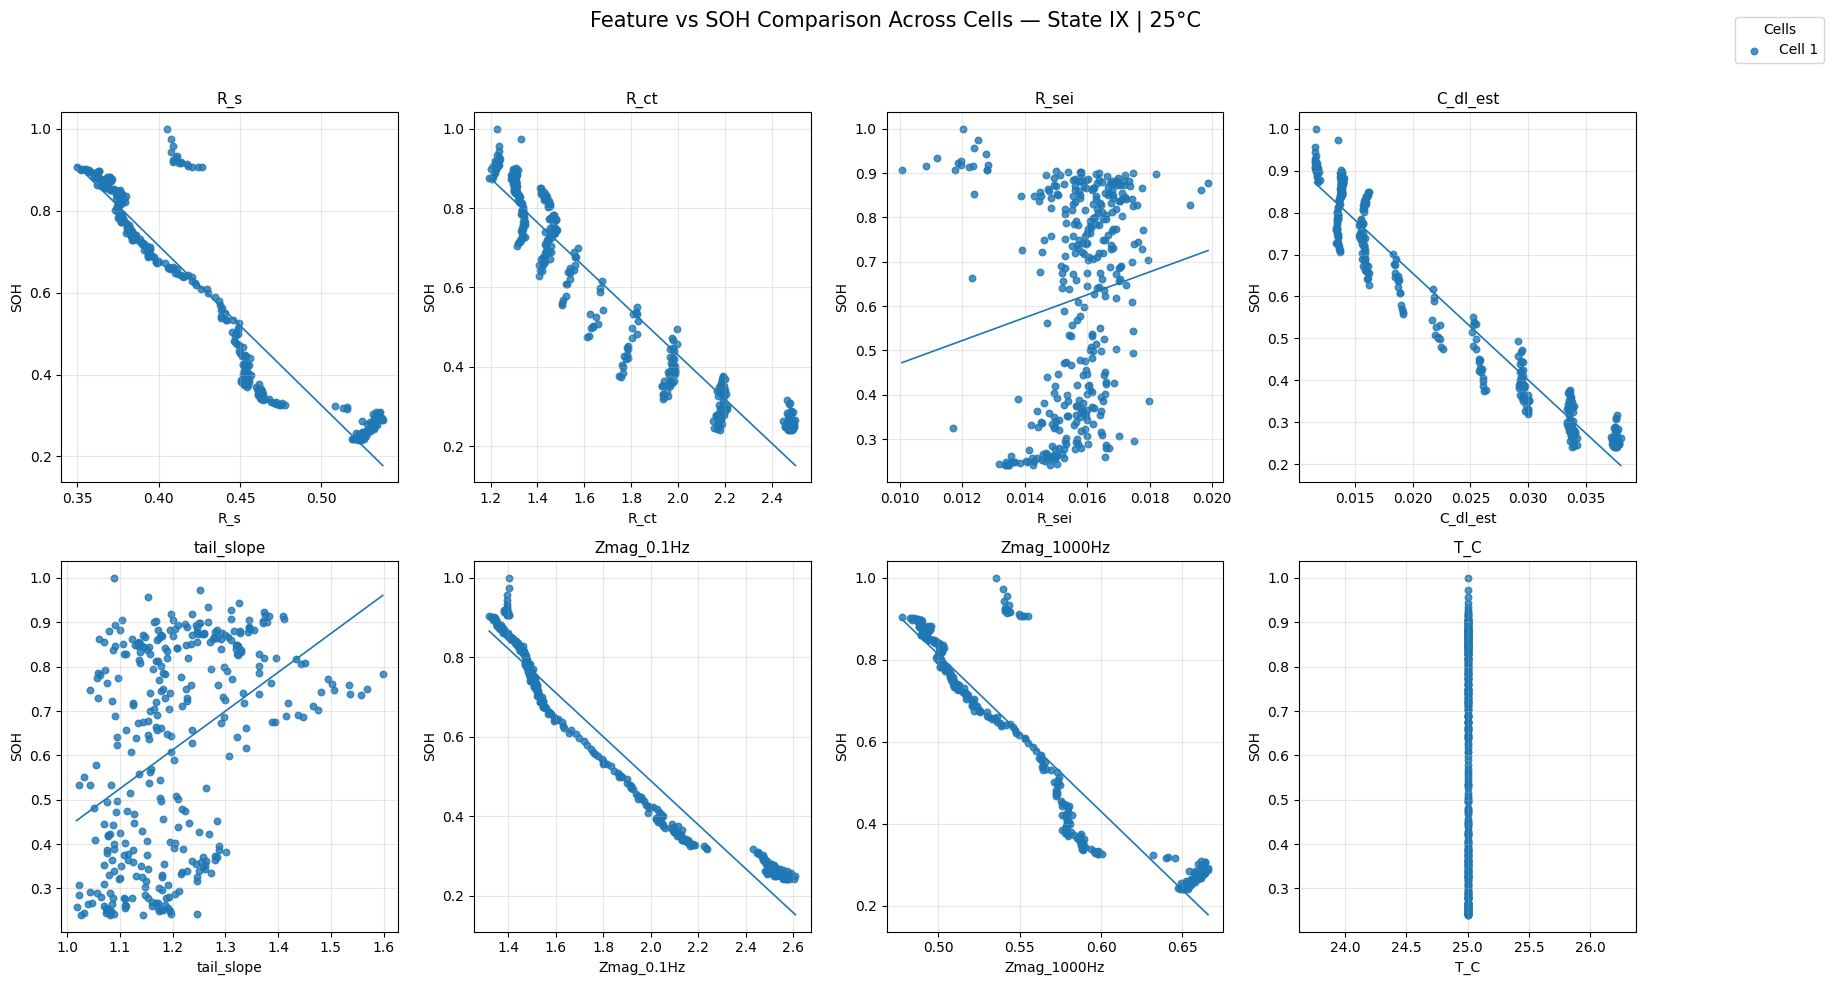

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STATE = "IX"
TEMP_C = 25
CELL_IDS = [1]

features = [
    "R_s", "R_ct", "R_sei", "C_dl_est",
    "tail_slope", "Zmag_0.1Hz", "Zmag_1000Hz", "T_C"
]

d = df[df["state"].astype(str) == str(STATE)].copy()

if TEMP_C is not None:
    d = d[d["T_C"] == TEMP_C].copy()

if CELL_IDS is not None:
    d = d[d["cell"].isin(CELL_IDS)].copy()

d = d.replace([np.inf, -np.inf], np.nan)
d = d.dropna(subset=["cycle", "SOH", "cell"] + features)
d = d.sort_values(["cell", "cycle"]).copy()

cells = sorted(d["cell"].unique())

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']
marker_map = {cell: markers[i % len(markers)] for i, cell in enumerate(cells)}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_map = {cell: colors[i % len(colors)] for i, cell in enumerate(cells)}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    for cell in cells:
        dc = d[d["cell"] == cell].copy()

        x = pd.to_numeric(dc[feat], errors="coerce").to_numpy()
        y = pd.to_numeric(dc["SOH"], errors="coerce").to_numpy()

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        if len(x) == 0:
            continue

        ax.scatter(
            x, y,
            s=22,
            alpha=0.8,
            marker=marker_map[cell],
            color=color_map[cell],
            label=f"Cell {cell}"
        )

        if len(x) >= 2:
            slope, intercept = np.polyfit(x, y, 1)
            xx = np.linspace(np.min(x), np.max(x), 100)
            ax.plot(xx, slope * xx + intercept, color=color_map[cell], linewidth=1.2)

    ax.set_title(feat, fontsize=11)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("SOH", fontsize=10)
    ax.grid(True, alpha=0.3)

# single legend for whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Cells", loc="upper right", bbox_to_anchor=(1.02, 0.98))

fig.suptitle(
    f"Feature vs SOH Comparison Across Cells — State {STATE}" +
    (f" | {TEMP_C}°C" if TEMP_C is not None else ""),
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.show()

In [55]:
"""
plot1_features_vs_cycles_by_temperature.py
============================================
Plots each EIS feature against cycle number, grouped by temperature
(25°C, 35°C, 45°C).  One figure per feature, three subplots per
figure (one per temperature).  Individual cells are shown as separate
lines so degradation trajectories are distinguishable.

Input
-----
CSV produced by your preprocessing pipeline, e.g.:
    final_7features_state_IX.csv
Columns expected (from your meta_cols + feature_cols):
    state, T_C, cell, cycle, capacity, SOH,
    R_s_rel, R_ct_rel, R_sei_rel, C_dl_log,
    tail_slope, Zmag_0.1Hz_rel, Zmag_1000Hz_rel, T_C

Usage
-----
Set CSV_PATH and STATE below, then run:
    python plot1_features_vs_cycles_by_temperature.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ──────────────────────────────────────────────────────────────
# USER SETTINGS — adjust these to match your files
# ──────────────────────────────────────────────────────────────
CSV_PATH = '/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_state_IX_norm.csv'   # path to your CSV
STATE    = "IX"                              # EIS measurement state to plot
SAVE_DIR = Path("figures_temp")             # folder for saved figures
SAVE_FIG = True                             # True = save PNG; False = show only
DPI      = 180                              # figure resolution

# Features to plot — use the column names that exist in your CSV
FEATURES = [
    "R_s",
    '''"R_ct_rel",
    "R_sei_rel",
    "C_dl_log",
    "tail_slope",
    "Zmag_0.1Hz_rel",
    "Zmag_1000Hz_rel",
    "T_C",'''
]

# Nicer axis labels for each feature
FEAT_LABELS = {
    "R_s_rel":        r"$R_{s,\mathrm{rel}}$ (normalised ohmic resistance)",
    "R_ct_rel":       r"$R_{ct,\mathrm{rel}}$ (normalised charge transfer resistance)",
    "R_sei_rel":      r"$R_{sei,\mathrm{rel}}$ (normalised SEI resistance)",
    "C_dl_log":       r"$C_{dl,\log}$ = log$_{10}$($C_{dl}$)  [log F]",
    "tail_slope":     r"$\sigma_W$ (Warburg tail slope)",
    "Zmag_0.1Hz_rel": r"$|Z|_{0.1\,\mathrm{Hz,rel}}$ (normalised impedance at 0.1 Hz)",
    "Zmag_1000Hz_rel":r"$|Z|_{1000\,\mathrm{Hz,rel}}$ (normalised impedance at 1000 Hz)",
    "T_C":            r"Temperature $T_C$ (°C)",
}

TEMPERATURES = [25, 35, 45]   # the three temperature conditions in your dataset
TEMP_COLORS  = {25: "#1d6fa4", 35: "#e07b00", 45: "#c0001a"}
TEMP_TITLES  = {25: "25 °C", 35: "35 °C", 45: "45 °C"}

CELLS_PER_TEMP = {
    25: [1],       # e.g. [1, 4, 8] to pick specific 25°C cells
    35: [1],       # e.g. [1, 2]
    45: [1],       # e.g. [1]
}

# cell-line styles so individual cells can be distinguished
LINE_STYLES = ["-", "--", "-.", ":", (0,(3,1,1,1)), (0,(5,2))]
MARKERS     = ["o", "s", "^", "D", "v", "P", "X", "<"]

# ──────────────────────────────────────────────────────────────
# LOAD & FILTER
# ──────────────────────────────────────────────────────────────
df_all = pd.read_csv(CSV_PATH)

# keep only the selected state
df_all = df_all[df_all["state"].astype(str) == str(STATE)].copy()

# coerce numerics
for col in ["cycle", "SOH", "T_C", "cell"] + FEATURES:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

df_all = df_all.replace([np.inf, -np.inf], np.nan)
df_all = df_all.sort_values(["T_C", "cell", "cycle"]).reset_index(drop=True)

if SAVE_FIG:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ──────────────────────────────────────────────────────────────
# PLOT — one figure per feature
# ──────────────────────────────────────────────────────────────
for feat in FEATURES:
    if feat not in df_all.columns:
        print(f"  [skip] column '{feat}' not found in CSV")
        continue

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 5),
        sharey=False,
        constrained_layout=True
    )
    fig.suptitle(
        f"Evolution of {FEAT_LABELS.get(feat, feat)} with Cycling\n"
        f"EIS State {STATE}  |  Comparison across temperatures",
        fontsize=13, fontweight="bold", y=1.02
    )

    for ax, temp in zip(axes, TEMPERATURES):
        d_temp = df_all[df_all["T_C"] == temp].copy()
        cells  = sorted(d_temp["cell"].unique())
        color  = TEMP_COLORS[temp]

        for i, cell in enumerate(cells):
            d_cell = d_temp[d_temp["cell"] == cell].dropna(
                subset=["cycle", feat]
            ).copy()
            if d_cell.empty:
                continue

            x = d_cell["cycle"].to_numpy()
            y = d_cell[feat].to_numpy()
            mask = np.isfinite(x) & np.isfinite(y)
            x, y = x[mask], y[mask]
            if len(x) == 0:
                continue

            ls = LINE_STYLES[i % len(LINE_STYLES)]
            mk = MARKERS[i % len(MARKERS)]

            ax.plot(
                x, y,
                linestyle=ls,
                marker=mk,
                markevery=max(1, len(x)//12),   # don't crowd markers
                markersize=4,
                linewidth=1.6,
                color=color,
                alpha=0.85,
                label=f"Cell {int(cell)}"
            )

        ax.set_title(TEMP_TITLES[temp], fontsize=12, fontweight="bold",
                     color=color, pad=6)
        ax.set_xlabel("Cycle number", fontsize=10)
        ax.set_ylabel(FEAT_LABELS.get(feat, feat), fontsize=9.5)
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(which="both", direction="in", labelsize=9)

        if cells:
            ax.legend(
                title="Cell", fontsize=8, title_fontsize=8.5,
                loc="best", framealpha=0.7
            )

    # add a thin coloured top-border strip per subplot to signal temperature
    for ax, temp in zip(axes, TEMPERATURES):
        ax.spines["top"].set_color(TEMP_COLORS[temp])
        ax.spines["top"].set_linewidth(3)

    if SAVE_FIG:
        fname = SAVE_DIR / f"plot1_{feat}_vs_cycles_by_temp.png"
        fig.savefig(fname, dpi=DPI, bbox_inches="tight")
        print(f"  Saved: {fname}")
    else:
        plt.show()

    plt.close(fig)

print("Plot 1 complete.")

  Saved: figures_temp/plot1_R_s_vs_cycles_by_temp.png
  [skip] column '"R_ct_rel",
    "R_sei_rel",
    "C_dl_log",
    "tail_slope",
    "Zmag_0.1Hz_rel",
    "Zmag_1000Hz_rel",
    "T_C",' not found in CSV
Plot 1 complete.


In [59]:
"""
plot1_features_vs_cycles_by_temperature.py
============================================
Plots each EIS feature against cycle number, grouped by temperature
(25°C, 35°C, 45°C).  One figure per feature, three subplots per
figure (one per temperature).  Individual cells are shown as separate
lines so degradation trajectories are distinguishable.

Input
-----
CSV produced by your preprocessing pipeline, e.g.:
    final_7features_state_IX.csv
Columns expected (from your meta_cols + feature_cols):
    state, T_C, cell, cycle, capacity, SOH,
    R_s_rel, R_ct_rel, R_sei_rel, C_dl_log,
    tail_slope, Zmag_0.1Hz_rel, Zmag_1000Hz_rel, T_C

Usage
-----
Set CSV_PATH and STATE below, then run:
    python plot1_features_vs_cycles_by_temperature.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ──────────────────────────────────────────────────────────────
# USER SETTINGS — adjust these to match your files
# ──────────────────────────────────────────────────────────────
CSV_PATH = "/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_state_V_norm.csv"   # path to your CSV
STATE    = "V"                              # EIS measurement state to plot
SAVE_DIR = Path("figures_temp")             # folder for saved figures
SAVE_FIG = True                             # True = save PNG; False = show only
DPI      = 180                              # figure resolution

# Features to plot — use the column names that exist in your CSV
FEATURES = [
    "R_s",
    '''"R_ct_rel",
    "R_sei_rel",
    "C_dl_log",
    "tail_slope",
    "Zmag_0.1Hz_rel",
    "Zmag_1000Hz_rel",
    "T_C",'''
]

# Nicer axis labels for each feature
FEAT_LABELS = {
    "R_s_rel":        r"$R_{s,\mathrm{rel}}$ (normalised ohmic resistance)",
    "R_ct_rel":       r"$R_{ct,\mathrm{rel}}$ (normalised charge transfer resistance)",
    "R_sei_rel":      r"$R_{sei,\mathrm{rel}}$ (normalised SEI resistance)",
    "C_dl_log":       r"$C_{dl,\log}$ = log$_{10}$($C_{dl}$)  [log F]",
    "tail_slope":     r"$\sigma_W$ (Warburg tail slope)",
    "Zmag_0.1Hz_rel": r"$|Z|_{0.1\,\mathrm{Hz,rel}}$ (normalised impedance at 0.1 Hz)",
    "Zmag_1000Hz_rel":r"$|Z|_{1000\,\mathrm{Hz,rel}}$ (normalised impedance at 1000 Hz)",
    "T_C":            r"Temperature $T_C$ (°C)",
}

TEMPERATURES = [25, 35, 45]   # the three temperature conditions in your dataset
TEMP_COLORS  = {25: "#1d6fa4", 35: "#e07b00", 45: "#c0001a"}
TEMP_TITLES  = {25: "25 °C", 35: "35 °C", 45: "45 °C"}

# ── CELL SELECTION ───────────────────────────────────────────
# Choose which cells to show for each temperature.
# Set a temperature key to None to show ALL cells at that temperature.
# Examples:
#   [1, 2, 3]   → show only cells 1, 2, 3
#   None        → show every cell available at that temperature
#
# 25°C cells available: 1,2,3,4,5,6,7,8
# 35°C cells available: 1,2
# 45°C cells available: 1,2
CELLS_PER_TEMP = {
    25: [1],       # e.g. [1, 4, 8] to pick specific 25°C cells
    35: [1],       # e.g. [1, 2]
    45: [1],       # e.g. [1]
}
# ─────────────────────────────────────────────────────────────

# cell-line styles so individual cells can be distinguished
LINE_STYLES = ["-", "--", "-.", ":", (0,(3,1,1,1)), (0,(5,2))]
MARKERS     = ["o", "s", "^", "D", "v", "P", "X", "<"]

# ──────────────────────────────────────────────────────────────
# LOAD & FILTER
# ──────────────────────────────────────────────────────────────
df_all = pd.read_csv(CSV_PATH)

# keep only the selected state
df_all = df_all[df_all["state"].astype(str) == str(STATE)].copy()

# coerce numerics
for col in ["cycle", "SOH", "T_C", "cell"] + FEATURES:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

df_all = df_all.replace([np.inf, -np.inf], np.nan)
df_all = df_all.sort_values(["T_C", "cell", "cycle"]).reset_index(drop=True)

if SAVE_FIG:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ──────────────────────────────────────────────────────────────
# PLOT — one figure per feature
# ──────────────────────────────────────────────────────────────
for feat in FEATURES:
    if feat not in df_all.columns:
        print(f"  [skip] column '{feat}' not found in CSV")
        continue

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 5),
        sharey=False,
        constrained_layout=True
    )
    fig.suptitle(
        f"Evolution of {FEAT_LABELS.get(feat, feat)} with Cycling\n"
        f"EIS State {STATE}  |  Comparison across temperatures",
        fontsize=13, fontweight="bold", y=1.02
    )

    for ax, temp in zip(axes, TEMPERATURES):
        d_temp = df_all[df_all["T_C"] == temp].copy()

        # apply per-temperature cell filter
        wanted = CELLS_PER_TEMP.get(temp, None)
        if wanted is not None:
            d_temp = d_temp[d_temp["cell"].isin(wanted)].copy()

        cells  = sorted(d_temp["cell"].unique())
        color  = TEMP_COLORS[temp]

        for i, cell in enumerate(cells):
            d_cell = d_temp[d_temp["cell"] == cell].dropna(
                subset=["cycle", feat]
            ).copy()
            if d_cell.empty:
                continue

            x = d_cell["cycle"].to_numpy()
            y = d_cell[feat].to_numpy()
            mask = np.isfinite(x) & np.isfinite(y)
            x, y = x[mask], y[mask]
            if len(x) == 0:
                continue

            ls = LINE_STYLES[i % len(LINE_STYLES)]
            mk = MARKERS[i % len(MARKERS)]

            ax.plot(
                x, y,
                linestyle=ls,
                marker=mk,
                markevery=max(1, len(x)//12),   # don't crowd markers
                markersize=4,
                linewidth=1.6,
                color=color,
                alpha=0.85,
                label=f"Cell {int(cell)}"
            )

        ax.set_title(TEMP_TITLES[temp], fontsize=12, fontweight="bold",
                     color=color, pad=6)
        ax.set_xlabel("Cycle number", fontsize=10)
        ax.set_ylabel(FEAT_LABELS.get(feat, feat), fontsize=9.5)
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(which="both", direction="in", labelsize=9)

        if cells:
            ax.legend(
                title="Cell", fontsize=8, title_fontsize=8.5,
                loc="best", framealpha=0.7
            )

    # add a thin coloured top-border strip per subplot to signal temperature
    for ax, temp in zip(axes, TEMPERATURES):
        ax.spines["top"].set_color(TEMP_COLORS[temp])
        ax.spines["top"].set_linewidth(3)

    if SAVE_FIG:
        fname = SAVE_DIR / f"plot1_{feat}_vs_cycles_by_temp.png"
        fig.savefig(fname, dpi=DPI, bbox_inches="tight")
        print(f"  Saved: {fname}")
    else:
        plt.show()

    plt.close(fig)

print("Plot 1 complete.")

  Saved: figures_temp/plot1_R_s_vs_cycles_by_temp.png
  [skip] column '"R_ct_rel",
    "R_sei_rel",
    "C_dl_log",
    "tail_slope",
    "Zmag_0.1Hz_rel",
    "Zmag_1000Hz_rel",
    "T_C",' not found in CSV
Plot 1 complete.


In [66]:
"""
plot2_features_vs_cycles_by_state.py
======================================
Plots each EIS feature against cycle number with one line per
measurement state (I-IX).  Two layout options:
  MODE = "overlay"  -> all 9 states on one axes per feature
  MODE = "grid"     -> 3x3 subplot grid, one panel per state

CSV loading options
-------------------
Option A (recommended): a SINGLE CSV that already has all 9 states
  stacked together with a 'state' column.  Set LOAD_SEPARATE = False.

Option B: 9 SEPARATE CSVs, one per state.  Set LOAD_SEPARATE = True
  and fill in SEPARATE_CSV_NAMES below with your actual file names.

Usage:  python plot2_features_vs_cycles_by_state.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from pathlib import Path

# ==============================================================
#  USER SETTINGS  --  only edit this block
# ==============================================================

BASE_DIR = Path(
    "/Users/yaswanthkanagarla/Desktop/Master_Thesis"
    "/BD_code/Battery_Diagnostics_Thesis/scripts"
)

# Folder where PNGs are saved (created automatically if missing)
SAVE_DIR = BASE_DIR / "figures_states"

SAVE_FIG = True   # True = save PNG;  False = plt.show()
DPI      = 180
MODE     = "overlay"   # "overlay" or "grid"

# ── CSV loading ───────────────────────────────────────────────
# Set LOAD_SEPARATE = False if you have one combined CSV.
# Set LOAD_SEPARATE = True  if you have one CSV per state.

LOAD_SEPARATE = True   # change to True if you have separate files

# Option A: single combined CSV (all 9 states in one file)
# Change this name to whatever your combined file is called.
#CSV_COMBINED_NAME = "all_states_features.csv"
#CSV_COMBINED      = BASE_DIR / CSV_COMBINED_NAME

# Option B: separate CSV per state.
# Fill in the exact file names as they appear in your folder.
# Leave any state as None if you do not have a file for it.
SEPARATE_CSV_NAMES = {
    "I":    "merged_eis_capacity_state_I_norm.csv",
    "II":   "merged_eis_capacity_state_II_norm.csv",
    "III":  "merged_eis_capacity_state_III_norm.csv",
    "IV":   "merged_eis_capacity_state_IV_norm.csv",
    "V":    "merged_eis_capacity_state_V_norm.csv",
    "VI":   "merged_eis_capacity_state_VI_norm.csv",
    "VII":  "merged_eis_capacity_state_VII_norm.csv",
    "VIII": "merged_eis_capacity_state_VIII_norm.csv",
    "IX":   "merged_eis_capacity_state_IX_norm.csv",   # <- your known filename
}

STATE_ORDER =["I","V","IX"] #["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX"]

# ── Temperature filter ────────────────────────────────────────
# Show only one temperature, or None for all
TEMP_C = 25   # 25, 35, 45, or None

# ── Global cell filter ────────────────────────────────────────
# Applied to every state unless overridden by CELLS_PER_STATE below.
# None  -> all cells;  list -> only those cell IDs
#   25 C : 1, 2, 3, 4, 5, 6, 7, 8
#   35 C : 1, 2
#   45 C : 1, 2
CELL_IDS = [1]   # e.g. [1, 4, 8]

# ── Per-state cell override ───────────────────────────────────
# Use this to pick different cells for individual states.
# None means "fall back to CELL_IDS".
# Example: show only cells 1 and 4 for State IX but all cells for I-VIII:
#   "IX":  [1, 4]
#   "I":   None   <- uses CELL_IDS
CELLS_PER_STATE = {
    "I":    None,
    "II":   None,
    "III":  None,
    "IV":   None,
    "V":    None,
    "VI":   None,
    "VII":  None,
    "VIII": None,
    "IX":   None,
}

# ── Features to plot ──────────────────────────────────────────
FEATURES = [
    "R_s_rel",
    "R_ct_rel",
    "R_sei_rel",
    "C_dl_log",
    "tail_slope",
    "Zmag_0.1Hz_rel",
    "Zmag_1000Hz_rel",
]

# ==============================================================
#  (nothing below this line normally needs editing)
# ==============================================================

FEAT_LABELS = {
    "R_s_rel":        r"$R_{s,\mathrm{rel}}$  (norm. ohmic resistance)",
    "R_ct_rel":       r"$R_{ct,\mathrm{rel}}$  (norm. charge transfer resistance)",
    "R_sei_rel":      r"$R_{sei,\mathrm{rel}}$  (norm. SEI resistance)",
    "C_dl_log":       r"$C_{dl,\log}$  [log$_{10}$ F]",
    "tail_slope":     r"$\sigma_W$  (Warburg tail slope)",
    "Zmag_0.1Hz_rel": r"$|Z|_{0.1\,\mathrm{Hz,rel}}$",
    "Zmag_1000Hz_rel":r"$|Z|_{1000\,\mathrm{Hz,rel}}$",
}

LINE_STYLES_STATE = {
    "I": "-", "II": "-", "III": "-", "IV": "-", "V": "-",
    "VI": "--", "VII": "--", "VIII": "--", "IX": "-",
}
LINE_WIDTH_STATE = {
    "I": 1.8, "II": 1.8, "III": 1.8, "IV": 1.8, "V": 1.8,
    "VI": 1.2, "VII": 1.2, "VIII": 1.2, "IX": 2.4,
}

cmap         = cm.get_cmap("tab10", len(STATE_ORDER))
STATE_COLORS = {s: cmap(i) for i, s in enumerate(STATE_ORDER)}

# ── load ──────────────────────────────────────────────────────
if LOAD_SEPARATE:
    print("Loading separate CSV files per state...")
    frames = []
    for state in STATE_ORDER:
        fname = SEPARATE_CSV_NAMES.get(state)
        if fname is None:
            print(f"  [skip] no filename set for state {state}")
            continue
        fpath = BASE_DIR / fname
        if not fpath.exists():
            print(f"  [skip] file not found: {fpath.name}")
            continue
        tmp = pd.read_csv(fpath)
        tmp["state"] = state
        frames.append(tmp)
        print(f"  Loaded state {state}: {len(tmp):,} rows  ({fpath.name})")
    if not frames:
        raise FileNotFoundError(
            "No CSV files could be loaded. "
            "Check SEPARATE_CSV_NAMES and BASE_DIR."
        )
    df_all = pd.concat(frames, ignore_index=True)
else:
    print(f"Loading combined CSV: {CSV_COMBINED}")
    if not CSV_COMBINED.exists():
        # helpful error: list what IS in the folder
        found_csvs = [p.name for p in BASE_DIR.glob("*.csv")] if BASE_DIR.exists() else []
        raise FileNotFoundError(
            f"\nFile not found:\n  {CSV_COMBINED}\n\n"
            f"CSVs found in BASE_DIR:\n"
            + ("\n".join(f"  {n}" for n in found_csvs) if found_csvs else "  (none)")
            + "\n\nEither change CSV_COMBINED_NAME or set LOAD_SEPARATE = True."
        )
    df_all = pd.read_csv(CSV_COMBINED)
    print(f"  Rows loaded: {len(df_all):,}")

# ── coerce + normalise state labels ──────────────────────────
for col in ["cycle", "SOH", "T_C", "cell"] + FEATURES:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

df_all = df_all.replace([np.inf, -np.inf], np.nan)
df_all["state"] = df_all["state"].astype(str).str.strip().str.upper()
df_all = df_all[df_all["state"].isin(STATE_ORDER)].copy()

# ── temperature filter ────────────────────────────────────────
if TEMP_C is not None:
    df_all = df_all[df_all["T_C"] == TEMP_C].copy()

df_all = df_all.sort_values(["state", "cell", "cycle"]).reset_index(drop=True)

# print what's available so the user can configure cell filters
print("\nCells available per state and temperature:")
for state in STATE_ORDER:
    d_s = df_all[df_all["state"] == state]
    if d_s.empty:
        print(f"  State {state:4s}: (no data)")
        continue
    for t in sorted(d_s["T_C"].dropna().unique()):
        cells = sorted(d_s.loc[d_s["T_C"] == t, "cell"].dropna().unique())
        print(f"  State {state:4s}  {int(t)} C -> cells: {[int(c) for c in cells]}")
print()

if SAVE_FIG:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Saving figures to: {SAVE_DIR}\n")

# ── helpers ───────────────────────────────────────────────────
def _get_cells_for_state(state):
    """Return the effective cell list for a given state."""
    wanted = CELLS_PER_STATE.get(state)
    if wanted is None:
        wanted = CELL_IDS
    return wanted   # None means all cells

def _apply_cell_filter(d, state):
    wanted = _get_cells_for_state(state)
    if wanted is not None:
        d = d[d["cell"].isin(wanted)]
    return d

def _aggregate(d, feat):
    """Per-cycle mean and std over all cells."""
    g = d.dropna(subset=["cycle", feat]).groupby("cycle")[feat]
    cy    = g.mean().index.to_numpy()
    ymean = g.mean().to_numpy()
    ystd  = g.std().fillna(0).to_numpy()
    return cy, ymean, ystd

# ── overlay plot ──────────────────────────────────────────────
def plot_overlay(feat, df):
    fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
    temp_str = f"{int(TEMP_C)} °C" if TEMP_C is not None else "all temperatures"
    fig.suptitle(
        f"Evolution of {FEAT_LABELS.get(feat, feat)} across EIS States\n"
        f"Temperature: {temp_str}  |  Mean ± std across cells",
        fontsize=13, fontweight="bold",
    )

    plotted = []
    for state in STATE_ORDER:
        d_s = _apply_cell_filter(df[df["state"] == state], state)
        if d_s.empty or feat not in d_s.columns:
            continue
        cy, ymean, ystd = _aggregate(d_s, feat)
        if len(cy) == 0:
            continue

        color = STATE_COLORS[state]
        ax.plot(
            cy, ymean,
            linestyle=LINE_STYLES_STATE.get(state, "-"),
            linewidth=LINE_WIDTH_STATE.get(state, 1.8),
            color=color,
            label=f"State {state}",
            zorder=3,
        )
        ax.fill_between(cy, ymean - ystd, ymean + ystd,
                        color=color, alpha=0.10, zorder=2)
        plotted.append(state)

    # highlight State IX
    if "IX" in plotted:
        d_ix = _apply_cell_filter(df[df["state"] == "IX"], "IX")
        cy, ymean, _ = _aggregate(d_ix, feat)
        ax.plot(cy, ymean, linewidth=3.2,
                color=STATE_COLORS["IX"], zorder=4)
        if len(cy) > 0:
            ax.annotate(
                "State IX (selected)",
                xy=(cy[-1], ymean[-1]),
                xytext=(cy[-1] - max(cy) * 0.15, ymean[-1] * 1.04),
                fontsize=8, color=STATE_COLORS["IX"],
                arrowprops=dict(arrowstyle="->",
                                color=STATE_COLORS["IX"], lw=0.9),
            )

    ax.set_xlabel("Cycle number", fontsize=11)
    ax.set_ylabel(FEAT_LABELS.get(feat, feat), fontsize=10)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(which="both", direction="in", labelsize=9)
    ax.legend(title="EIS State", fontsize=8.5, title_fontsize=9,
              ncol=3, loc="best", framealpha=0.8)
    return fig

# ── grid plot ─────────────────────────────────────────────────
def plot_grid(feat, df):
    fig, axes = plt.subplots(
        3, 3, figsize=(15, 11),
        sharex=False, sharey=True, constrained_layout=True,
    )
    axes_flat = axes.flatten()
    temp_str = f"{int(TEMP_C)} °C" if TEMP_C is not None else "all temperatures"
    fig.suptitle(
        f"Evolution of {FEAT_LABELS.get(feat, feat)} — one panel per EIS State\n"
        f"Temperature: {temp_str}",
        fontsize=13, fontweight="bold",
    )

    for ax, state in zip(axes_flat, STATE_ORDER):
        d_s = _apply_cell_filter(df[df["state"] == state], state)
        color = STATE_COLORS[state]

        if d_s.empty or feat not in d_s.columns:
            ax.set_visible(False)
            continue

        cells = sorted(d_s["cell"].dropna().unique())
        for cell in cells:
            d_c = d_s[d_s["cell"] == cell].dropna(subset=["cycle", feat])
            x = d_c["cycle"].to_numpy()
            y = d_c[feat].to_numpy()
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() == 0:
                continue
            ax.plot(x[mask], y[mask], linewidth=1.3,
                    alpha=0.75, color=color, label=f"Cell {int(cell)}")

        cy, ymean, _ = _aggregate(d_s, feat)
        if len(cy) > 0:
            ax.plot(cy, ymean, linewidth=2.5, color="black",
                    alpha=0.6, linestyle="--", label="Mean")

        ax.set_title(f"State {state}", fontsize=10,
                     fontweight="bold", color=color, pad=4)
        ax.set_xlabel("Cycle", fontsize=8)
        ax.set_ylabel(FEAT_LABELS.get(feat, feat), fontsize=7.5)
        ax.grid(True, alpha=0.2, linestyle="--")
        ax.tick_params(labelsize=8)

        if state in ("VI", "VII", "VIII"):
            ax.text(0.97, 0.97, "sparse data",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=7, color="gray", fontstyle="italic")

    return fig

# ── main loop ─────────────────────────────────────────────────
for feat in FEATURES:
    if feat not in df_all.columns:
        print(f"  [skip] '{feat}' not in dataframe columns")
        continue

    fig = plot_overlay(feat, df_all) if MODE == "overlay" \
          else plot_grid(feat, df_all)

    if SAVE_FIG:
        tag   = "overlay" if MODE == "overlay" else "grid"
        fname = SAVE_DIR / f"plot2_{feat}_{tag}_by_state.png"
        fig.savefig(fname, dpi=DPI, bbox_inches="tight")
        print(f"  Saved: {fname.name}")
    else:
        plt.show()

    plt.close(fig)

print("\nPlot 2 complete.")

/var/folders/2t/k392bwxd4tb6pyly82dg4pqw0000gn/T/ipykernel_8389/3398088182.py:135: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap         = cm.get_cmap("tab10", len(STATE_ORDER))


Loading separate CSV files per state...
  Loaded state I: 2,741 rows  (merged_eis_capacity_state_I_norm.csv)
  Loaded state V: 2,597 rows  (merged_eis_capacity_state_V_norm.csv)
  Loaded state IX: 2,736 rows  (merged_eis_capacity_state_IX_norm.csv)

Cells available per state and temperature:
  State I     25 C -> cells: [1, 2, 3, 4, 5, 6, 7, 8]
  State V     25 C -> cells: [1, 2, 3, 4, 5, 6, 7, 8]
  State IX    25 C -> cells: [1, 2, 3, 4, 5, 6, 7, 8]

Saving figures to: /Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/figures_states

  Saved: plot2_R_s_rel_overlay_by_state.png
  Saved: plot2_R_ct_rel_overlay_by_state.png
  Saved: plot2_R_sei_rel_overlay_by_state.png
  Saved: plot2_C_dl_log_overlay_by_state.png
  Saved: plot2_tail_slope_overlay_by_state.png
  Saved: plot2_Zmag_0.1Hz_rel_overlay_by_state.png
  Saved: plot2_Zmag_1000Hz_rel_overlay_by_state.png

Plot 2 complete.


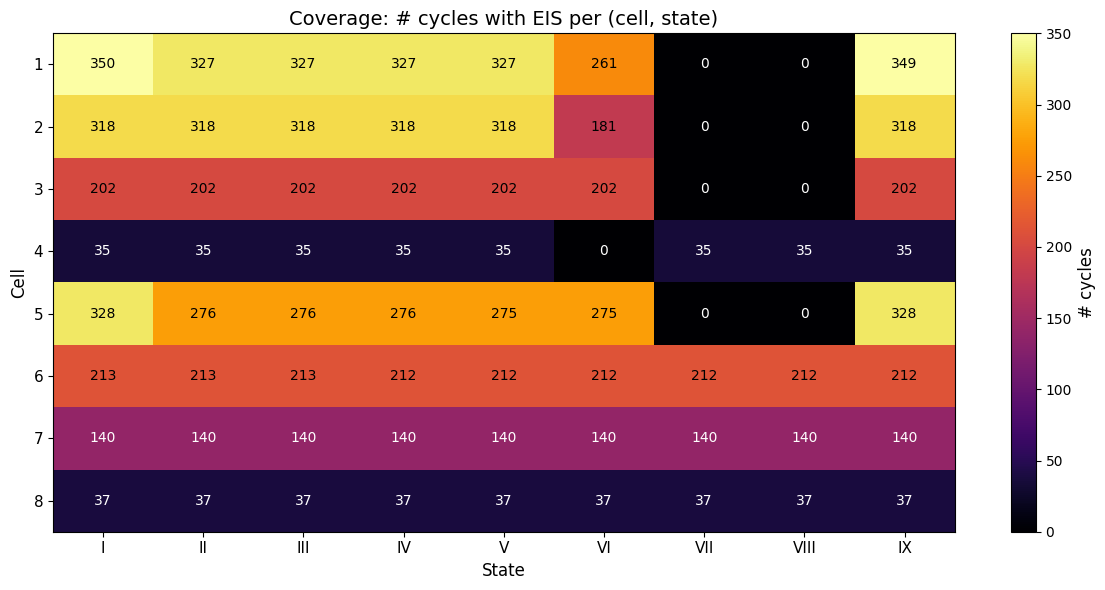

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_final.csv')  # <- change path if needed
# Example:
# df columns should contain: cell, state, cycle
# Replace these names if your column names are different

# Count number of cycles for each cell-state combination
coverage = (
    df.groupby(["cell", "state"])["cycle"]
      .nunique()   # use .count() if each row is already one cycle measurement
      .unstack(fill_value=0)
)

# Optional: enforce custom order of states
state_order = ["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX"]
coverage = coverage.reindex(columns=state_order, fill_value=0)

# Optional: enforce custom order of cells
cell_order = sorted(coverage.index)   # or give your own list
coverage = coverage.reindex(cell_order)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(coverage.values, aspect="auto", cmap="inferno")

# Axis labels
ax.set_xticks(np.arange(len(coverage.columns)))
ax.set_xticklabels(coverage.columns, fontsize=11)
ax.set_yticks(np.arange(len(coverage.index)))
ax.set_yticklabels(coverage.index, fontsize=11)

ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Cell", fontsize=12)
ax.set_title("Coverage: # cycles with EIS per (cell, state)", fontsize=14)

# Add numbers inside each cell
for i in range(coverage.shape[0]):
    for j in range(coverage.shape[1]):
        val = coverage.iloc[i, j]
        text_color = "white" if val < coverage.values.max() * 0.5 else "black"
        ax.text(j, i, str(val), ha="center", va="center", color=text_color, fontsize=10)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("# cycles", fontsize=12)

plt.tight_layout()
plt.show()

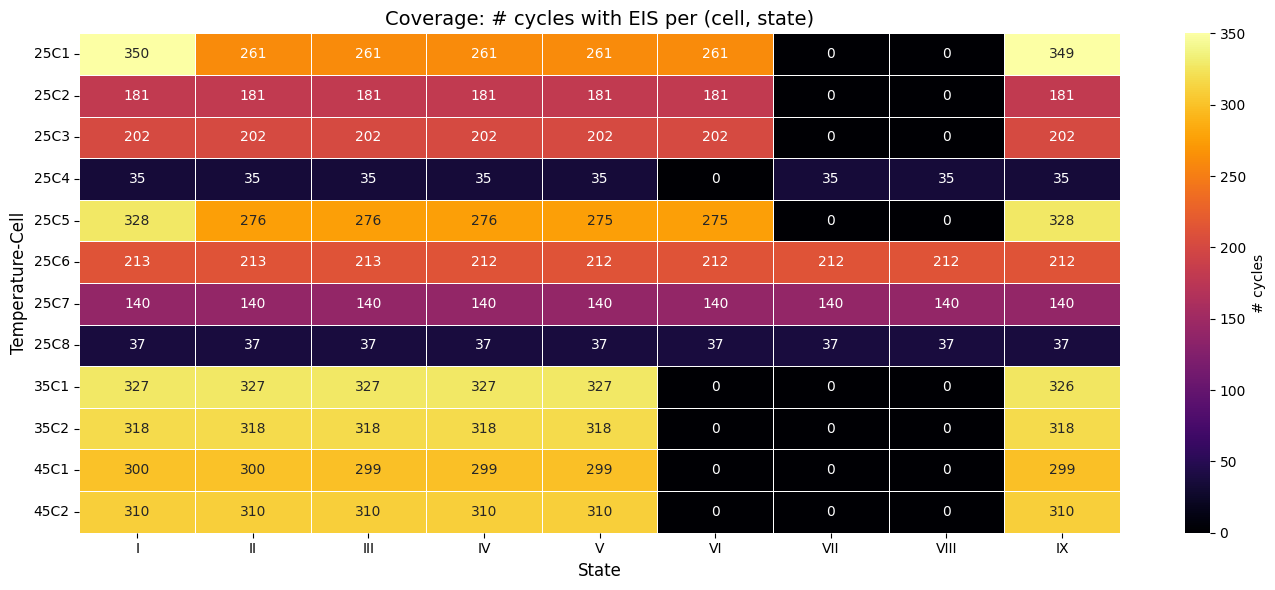

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1️⃣ Load Data
# =========================
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_final.csv')

# =========================
# 2️⃣ Create combined label (Temperature + Cell)
# =========================
# This assumes:
# df has columns: 'cell', 'T_C', 'state', 'cycle'

df["cell_temp"] = df["T_C"].astype(str) + "C" + df["cell"].astype(str)

# =========================
# 3️⃣ Create coverage table
# =========================
coverage = (
    df.groupby(["cell_temp", "state"])["cycle"]
      .nunique()   # change to .count() if needed
      .unstack(fill_value=0)
)

# =========================
# 4️⃣ Order states
# =========================
state_order = ["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX"]
coverage = coverage.reindex(columns=[s for s in state_order if s in coverage.columns], fill_value=0)

# =========================
# 5️⃣ Sort cells by temperature then cell number
# =========================
def sort_key(x):
    temp = int(x.split("C")[0])
    cell = int(x.split("C")[1])
    return (temp, cell)

coverage = coverage.reindex(sorted(coverage.index, key=sort_key))

# =========================
# 6️⃣ Plot Heatmap (Thesis Style)
# =========================
plt.figure(figsize=(14, 6))

ax = sns.heatmap(
    coverage,
    annot=True,
    fmt="d",
    cmap="inferno",   # try: viridis, magma, YlGnBu
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"label": "# cycles"}
)

# Labels
ax.set_title("Coverage: # cycles with EIS per (cell, state)", fontsize=14)
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Temperature-Cell", fontsize=12)

# Ticks
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# =========================
# 7️⃣ Save Figure (Optional)
# =========================
# plt.savefig("coverage_heatmap.png", dpi=300, bbox_inches="tight")

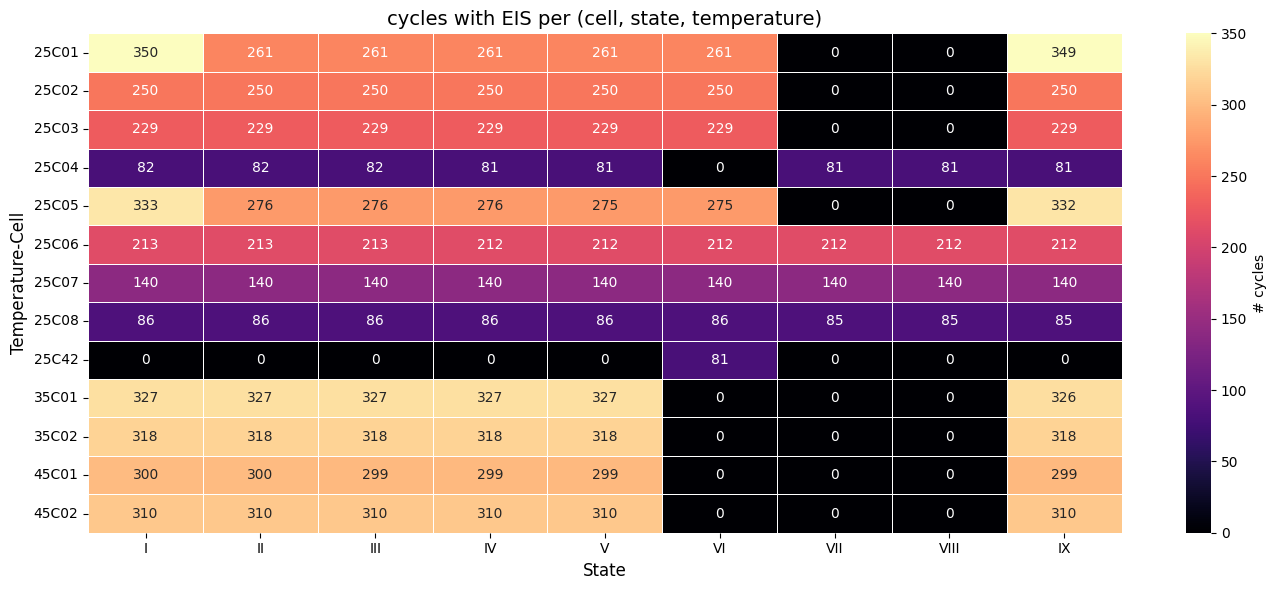

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1️⃣ Manual cycle counts
# =========================
manual_counts = {
    "25C01": {"I": 350, "II": 261, "III": 261, "IV": 261, "V": 261, "VI": 261, "VII": 0, "VIII": 0, "IX": 349},
    "25C02": {"I": 250, "II": 250, "III": 250, "IV": 250, "V": 250, "VI": 250, "VII": 0, "VIII": 0, "IX": 250},
    "25C03": {"I": 229, "II": 229, "III": 229, "IV": 229, "V": 229, "VI": 229, "VII": 0, "VIII": 0, "IX": 229},
    "25C04": {"I": 82, "II": 82, "III": 82, "IV": 81, "V": 81, "VI": 0, "VII": 81, "VIII": 81, "IX": 81},
    "25C05": {"I": 333, "II": 276, "III": 276, "IV": 276, "V": 275, "VI": 275, "VII": 0, "VIII": 0, "IX": 332},
    "25C06": {"I": 213, "II": 213, "III": 213, "IV": 212, "V": 212, "VI": 212, "VII": 212, "VIII": 212, "IX": 212},
    "25C07": {"I": 140, "II": 140, "III": 140, "IV": 140, "V": 140, "VI": 140, "VII": 140, "VIII": 140, "IX": 140},
    "25C08": {"I": 86, "II": 86, "III": 86, "IV": 86, "V": 86, "VI": 86, "VII": 85, "VIII": 85, "IX": 85},
    "25C42": {"I": 0, "II": 0, "III": 0, "IV": 0, "V": 0, "VI": 81, "VII": 0, "VIII": 0, "IX": 0},
    "35C01": {"I": 327, "II": 327, "III": 327, "IV": 327, "V": 327, "VI": 0, "VII": 0, "VIII": 0, "IX": 326},
    "35C02": {"I": 318, "II": 318, "III": 318, "IV": 318, "V": 318, "VI": 0, "VII": 0, "VIII": 0, "IX": 318},
    "45C01": {"I": 300, "II": 300, "III": 299, "IV": 299, "V": 299, "VI": 0, "VII": 0, "VIII": 0, "IX": 299},
    "45C02": {"I": 310, "II": 310, "III": 310, "IV": 310, "V": 310, "VI": 0, "VII": 0, "VIII": 0, "IX": 310},
}

coverage = pd.DataFrame.from_dict(manual_counts, orient="index").fillna(0).astype(int)

# =========================
# 2️⃣ Order rows/columns
# =========================
state_order = ["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX"]
coverage = coverage.reindex(columns=state_order, fill_value=0)

cell_order = [
    "25C01", "25C02", "25C03", "25C04", "25C05", "25C06", "25C07", "25C08","25C42",
    "35C01", "35C02",
    "45C01", "45C02"
]
coverage = coverage.reindex(cell_order)

# =========================
# 3️⃣ Plot heatmap
# =========================
plt.figure(figsize=(14, 6))

ax = sns.heatmap(
    coverage,
    annot=True,
    fmt="d",
    cmap="magma",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "# cycles"}
)

ax.set_title("cycles with EIS per (cell, state, temperature)", fontsize=14)
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Temperature-Cell", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

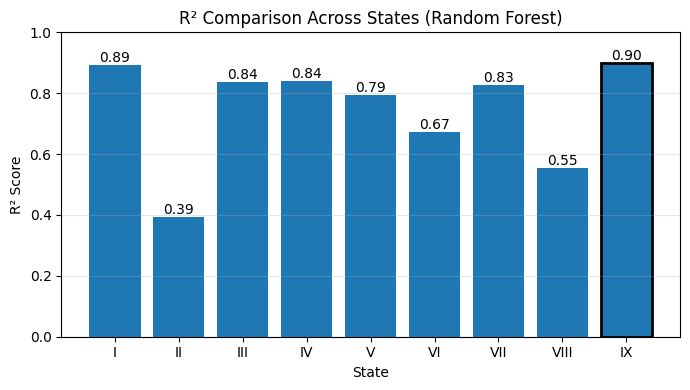

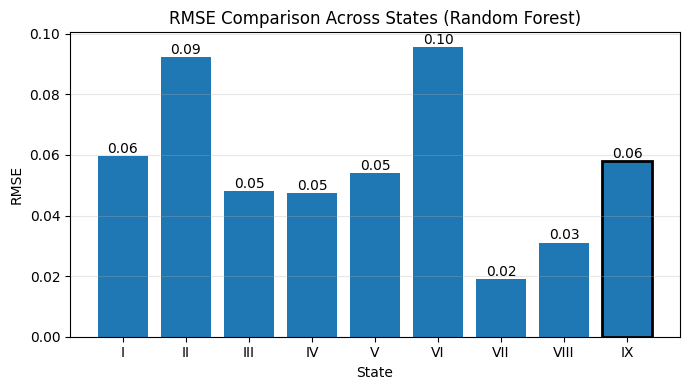

In [26]:
import matplotlib.pyplot as plt

# Example data (replace with your actual values)
states = ["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX"]

r2_scores = [0.8926, 0.3948, 0.8354, 0.8406, 0.7936, 0.6731, 0.8283, 0.5534, 0.8978]
rmse_scores = [0.05966, 0.0923, 0.0481, 0.0474, 0.0539, 0.0957, 0.0192, 0.0311, 0.0580]

# ---- R2 Plot ----
plt.figure(figsize=(7,4))
bars = plt.bar(states, r2_scores)
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
# Highlight best state (State 9)
bars[-1].set_edgecolor('black')
bars[-1].set_linewidth(2)

plt.xlabel("State")
plt.ylabel("R² Score")
plt.title("R² Comparison Across States (Random Forest)")
plt.ylim(0, 1)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# ---- RMSE Plot ----
plt.figure(figsize=(7,4))
bars = plt.bar(states, rmse_scores)
for i, v in enumerate(rmse_scores):
    plt.text(i, v + 0.001, f"{v:.2f}", ha='center')
# Highlight best state (State 9)
bars[-1].set_edgecolor('black')
bars[-1].set_linewidth(2)


plt.xlabel("State")
plt.ylabel("RMSE")
plt.title("RMSE Comparison Across States (Random Forest)")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()